# Post-process, evidence and interactive figures

This notebook reads saved out-of-sample artifacts only; it does not retrain models or call an API.

In [3]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))
from us10y_fomc.config import ProjectPaths
from us10y_fomc.reporting import build_postprocess_report
paths = ProjectPaths(ROOT).ensure()
summary = build_postprocess_report(paths)
display(summary)

Bootstrap fusion_bp vs price_only_bp:   0%|          | 0/5000 [00:00<?, ?draw/s]

Bootstrap fusion_bp vs rate_only_bp:   0%|          | 0/5000 [00:00<?, ?draw/s]

Bootstrap fusion_bp vs shuffled_text_bp:   0%|          | 0/5000 [00:00<?, ?draw/s]

{'n_oos': 178,
 'pooled_interval_coverage': 0.9269662921348315,
 'pooled_mean_interval_width_bp': 72.1602768,
 'models': {'fusion': {'mae_bp': 13.330631674438203,
   'rmse_bp': 17.341463925703362,
   'balanced_accuracy': 0.2880646163404784,
   'macro_f1': 0.285235049243578},
  'price_only': {'mae_bp': 12.15387481174326,
   'rmse_bp': 16.574297470604996,
   'balanced_accuracy': 0.2966076421248835,
   'macro_f1': 0.2965362956105839},
  'rate_only': {'mae_bp': 13.191445817168539,
   'rmse_bp': 16.477372807928575,
   'balanced_accuracy': 0.3009920265092679,
   'macro_f1': 0.30158220331260277},
  'shuffled_text': {'mae_bp': 13.26191301210674,
   'rmse_bp': 17.404481128296315,
   'balanced_accuracy': 0.3098208553380967,
   'macro_f1': 0.3103384939891099}},
 'paired_tests': {'fusion_vs_price_only': {'dm_statistic': 1.7983204542437163,
   'p_value': 0.07383029489270625,
   'mean_loss_difference': 1.1767568626949438},
  'bootstrap_fusion_vs_price_only': {'mean_difference': 1.1770443326551139,
 

In [4]:
pred = pd.read_csv(paths.outputs/'predictions'/'walk_forward_predictions.csv', parse_dates=['meeting_date','target_date'])
long = pred.melt(id_vars=['meeting_date','truth_bp'], value_vars=['fusion_bp','price_only_bp','rate_only_bp','shuffled_text_bp'], var_name='model', value_name='forecast_bp')
fig = px.line(long, x='meeting_date', y='forecast_bp', color='model', title='Walk-forward forecasts')
fig.add_scatter(x=pred.meeting_date, y=pred.truth_bp, mode='markers', name='realised', marker_color='black')
fig.show()

In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=pred.meeting_date, y=pred.fusion_upper_bp, mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=pred.meeting_date, y=pred.fusion_lower_bp, mode='lines', fill='tonexty', name='conformal interval'))
fig.add_trace(go.Scatter(x=pred.meeting_date, y=pred.fusion_bp, mode='lines', name='fusion median'))
fig.add_trace(go.Scatter(x=pred.meeting_date, y=pred.truth_bp, mode='markers', name='realised'))
fig.update_layout(title='Fold-calibrated fusion interval', yaxis_title='basis points')
fig.show()

In [6]:
error_rows = []
for model in tqdm(['fusion','price_only','rate_only','shuffled_text'], desc='Absolute-error table', unit='model', leave=False):
    for value in np.abs(pred.truth_bp - pred[f'{model}_bp']):
        error_rows.append({'model': model, 'absolute_error_bp': value})
px.box(pd.DataFrame(error_rows), x='model', y='absolute_error_bp', points=False, title='Paired OOS error distributions').show()

Absolute-error table:   0%|          | 0/4 [00:00<?, ?model/s]

In [7]:
attention_files = sorted((paths.outputs/'attention').glob('fold_*_price_to_event.csv'))
if attention_files:
    attention = pd.concat([pd.read_csv(path) for path in tqdm(attention_files, desc='Attention tables', unit='fold', leave=False)], ignore_index=True)
    mean_attention = attention.groupby('event_token', as_index=False).attention.mean().sort_values('attention')
    px.bar(mean_attention, x='attention', y='event_token', orientation='h', title='Mean price-to-event attention').show()
else:
    print('No attention files yet.')

Attention tables:   0%|          | 0/8 [00:00<?, ?fold/s]

Attention is a learned routing diagnostic, not a causal attribution. Model claims should be based on paired out-of-sample errors, the shuffled-text control, the rate-only control and uncertainty intervals.

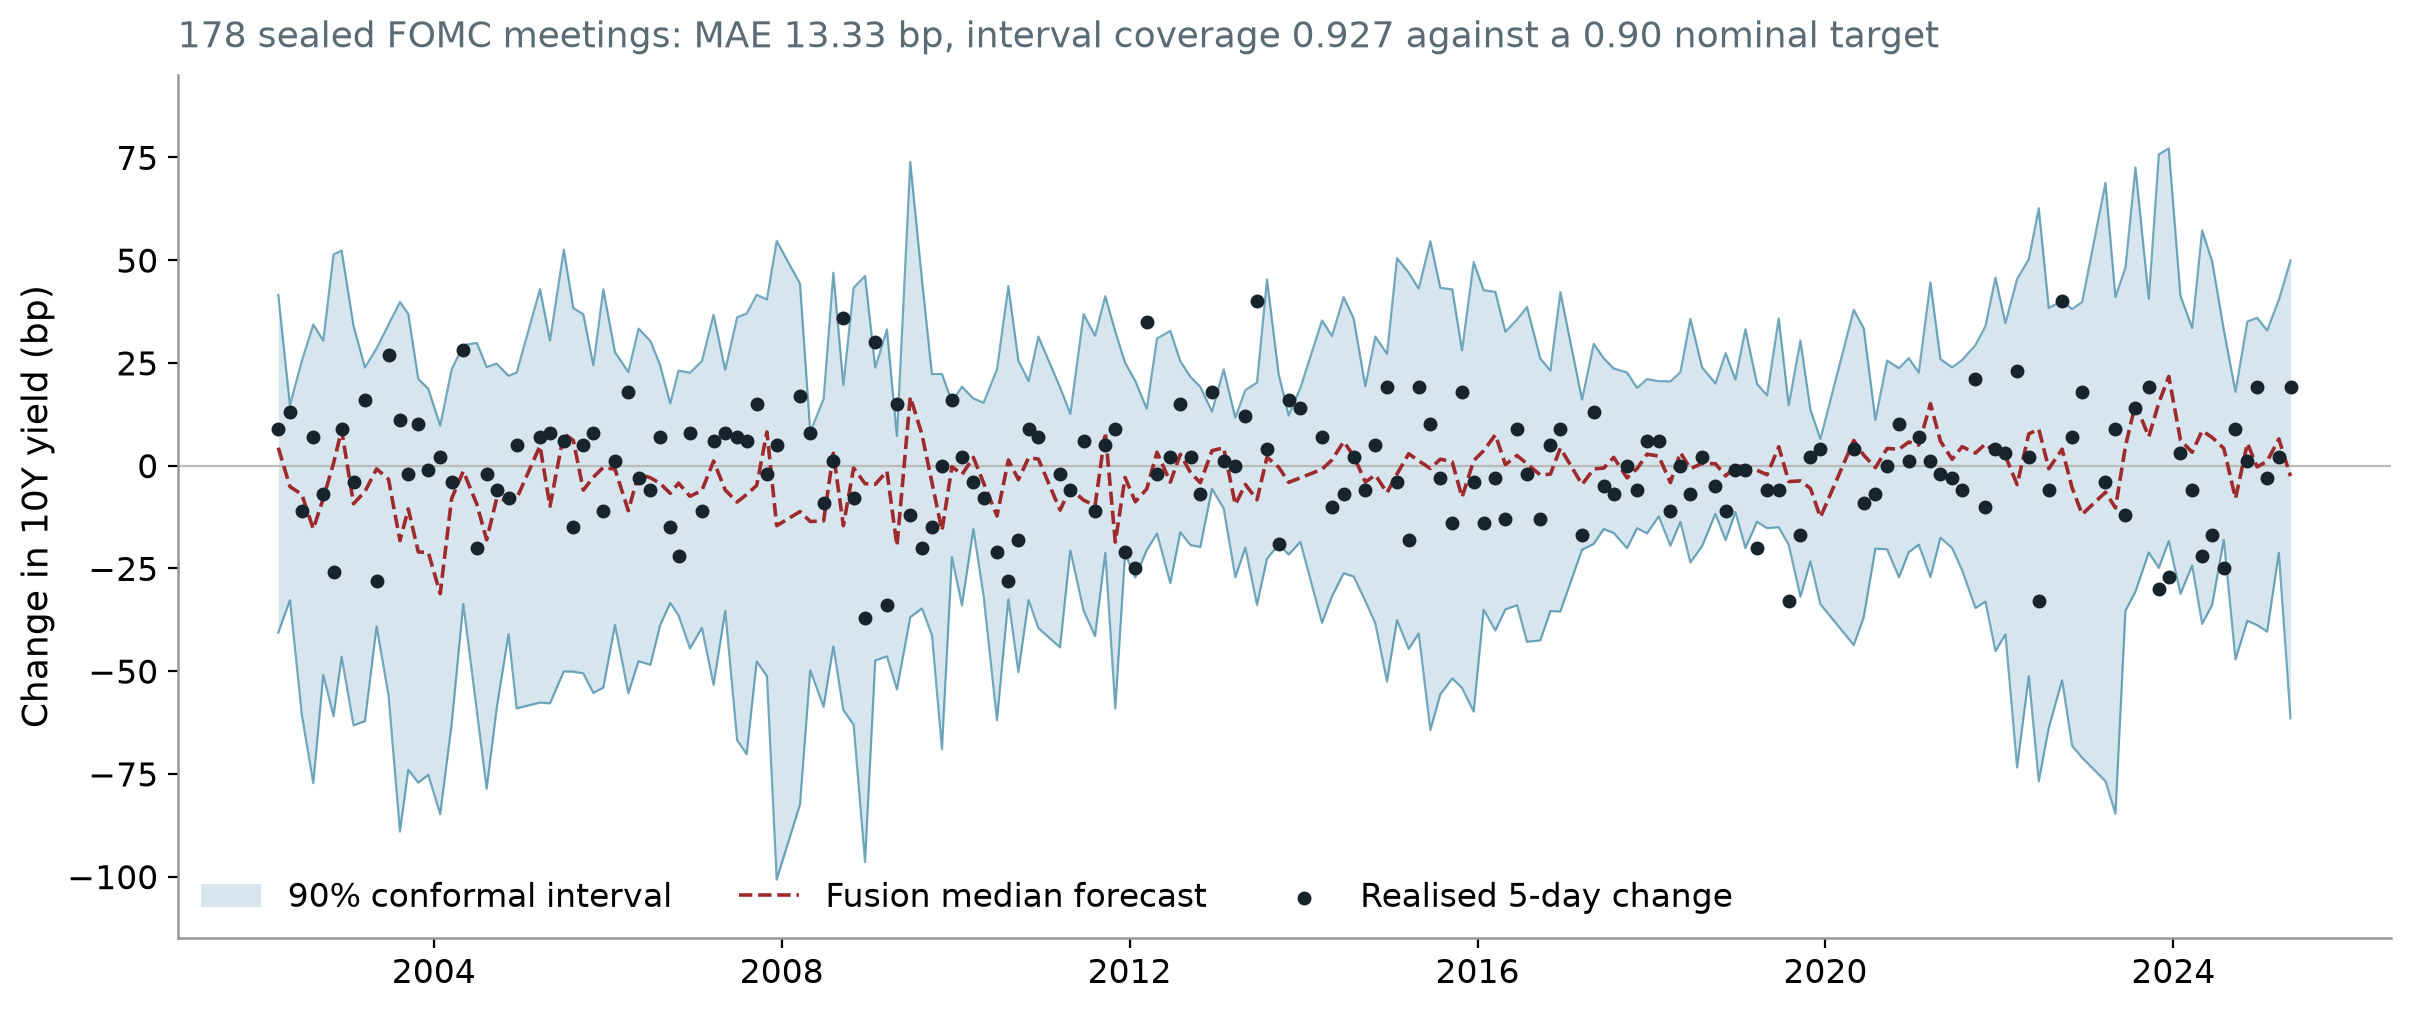

In [8]:
# Fusion forecast with conformal interval
import matplotlib.pyplot as plt

TEAL, RED, GREY, LIGHT, INK = "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

p = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date"],
).sort_values("meeting_date")

coverage = ((p.truth_bp >= p.fusion_lower_bp) & (p.truth_bp <= p.fusion_upper_bp)).mean()
mae = (p.truth_bp - p.fusion_bp).abs().mean()

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(p.meeting_date, p.fusion_lower_bp, p.fusion_upper_bp,
                color=LIGHT, alpha=0.85, lw=0, label="90% conformal interval")
ax.plot(p.meeting_date, p.fusion_lower_bp, color=TEAL, lw=0.8, alpha=0.6)
ax.plot(p.meeting_date, p.fusion_upper_bp, color=TEAL, lw=0.8, alpha=0.6)
ax.axhline(0, color="#BBBBBB", lw=0.8)
ax.plot(p.meeting_date, p.fusion_bp, color=RED, lw=1.3, ls="--",
        label="Fusion median forecast")
ax.scatter(p.meeting_date, p.truth_bp, s=16, color=INK, zorder=3,
           label="Realised 5-day change")
ax.set_ylabel("Change in 10Y yield (bp)")
ax.set_ylim(-115, 95)
ax.legend(frameon=False, loc="lower left", ncol=3,
          columnspacing=2.0, handlelength=1.8, borderpad=0.2)
ax.set_title(
    f"{len(p)} sealed FOMC meetings: MAE {mae:.2f} bp, "
    f"interval coverage {coverage:.3f} against a 0.90 nominal target",
    loc="left", color=GREY, fontsize=13, pad=10,
)
fig.tight_layout(pad=0.4)
plt.show()

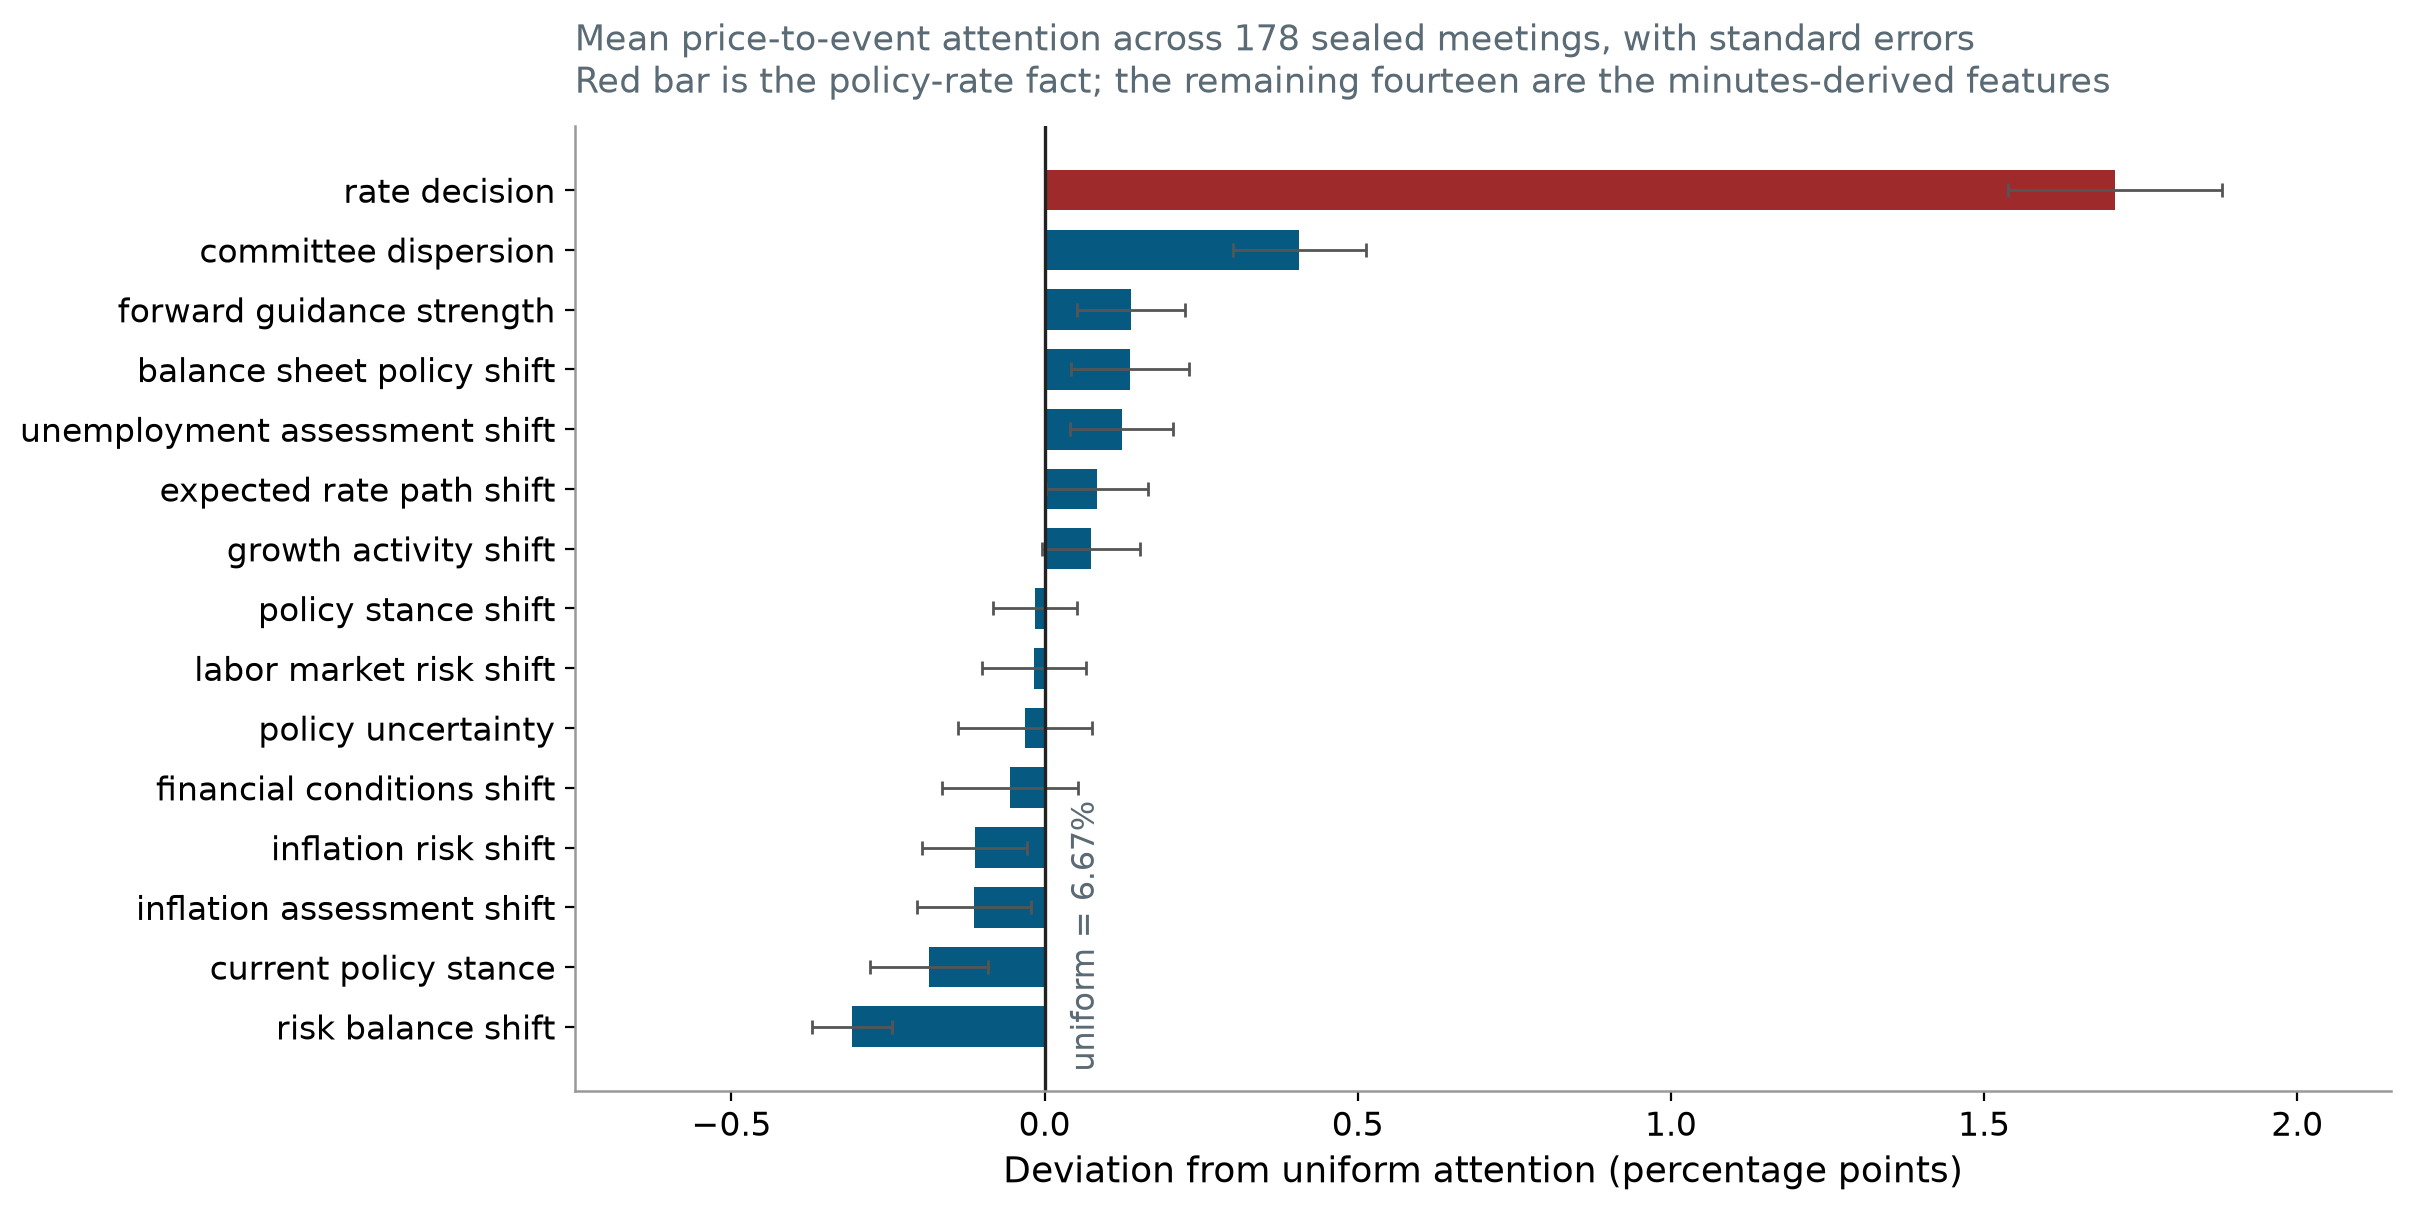

,mean,dev,se_pp,count
event_token,,,,
rate_decision,0.0838,1.7086,0.1709,178
committee_dispersion,0.0707,0.4070,0.1059,178
forward_guidance_strength,0.0681,0.1386,0.0862,178
balance_sheet_policy_shift,0.0680,0.1362,0.0938,130
unemployment_assessment_shift,0.0679,0.1229,0.0819,178
expected_rate_path_shift,0.0675,0.0835,0.0816,178
growth_activity_shift,0.0674,0.0738,0.0785,178
policy_stance_shift,0.0665,-0.0154,0.0668,178
labor_market_risk_shift,0.0665,-0.0173,0.0829,178


In [9]:
# Price-to-event attention, expressed as deviation from uniform allocation
import matplotlib.pyplot as plt
import numpy as np

BLUE, RED, GREY = "#065A82", "#9E2A2B", "#5A6B75"

files = sorted((paths.outputs / "attention").glob("fold_*_price_to_event.csv"))
att = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
uniform = 1 / att.event_token.nunique()

g = att.groupby("event_token").attention.agg(["mean", "std", "count"])
g["se_pp"] = g["std"] / np.sqrt(g["count"]) * 100
g["dev"] = (g["mean"] - uniform) * 100
g = g.sort_values("dev")

labels = [t.replace("_", " ") for t in g.index]
colors = [RED if t == "rate_decision" else BLUE for t in g.index]

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(g))
ax.barh(y, g.dev, xerr=g.se_pp, color=colors, height=0.68,
        error_kw=dict(lw=1.0, ecolor="#555555", capsize=2.5))
ax.axvline(0, color="#222222", lw=1.2)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Deviation from uniform attention (percentage points)")
ax.set_xlim(-0.75, 2.15)
ax.text(0.04, -0.75, f"uniform = {uniform * 100:.2f}%", fontsize=11.5,
        color=GREY, rotation=90, va="bottom")
ax.set_title(
    f"Mean price-to-event attention across {att.meeting_date.nunique()} sealed "
    "meetings, with standard errors\nRed bar is the policy-rate fact; the "
    "remaining fourteen are the minutes-derived features",
    loc="left", color=GREY, fontsize=12.5, pad=12,
)
fig.tight_layout(pad=0.4)
plt.show()

display(g[["mean", "dev", "se_pp", "count"]].sort_values("dev", ascending=False).round(4))

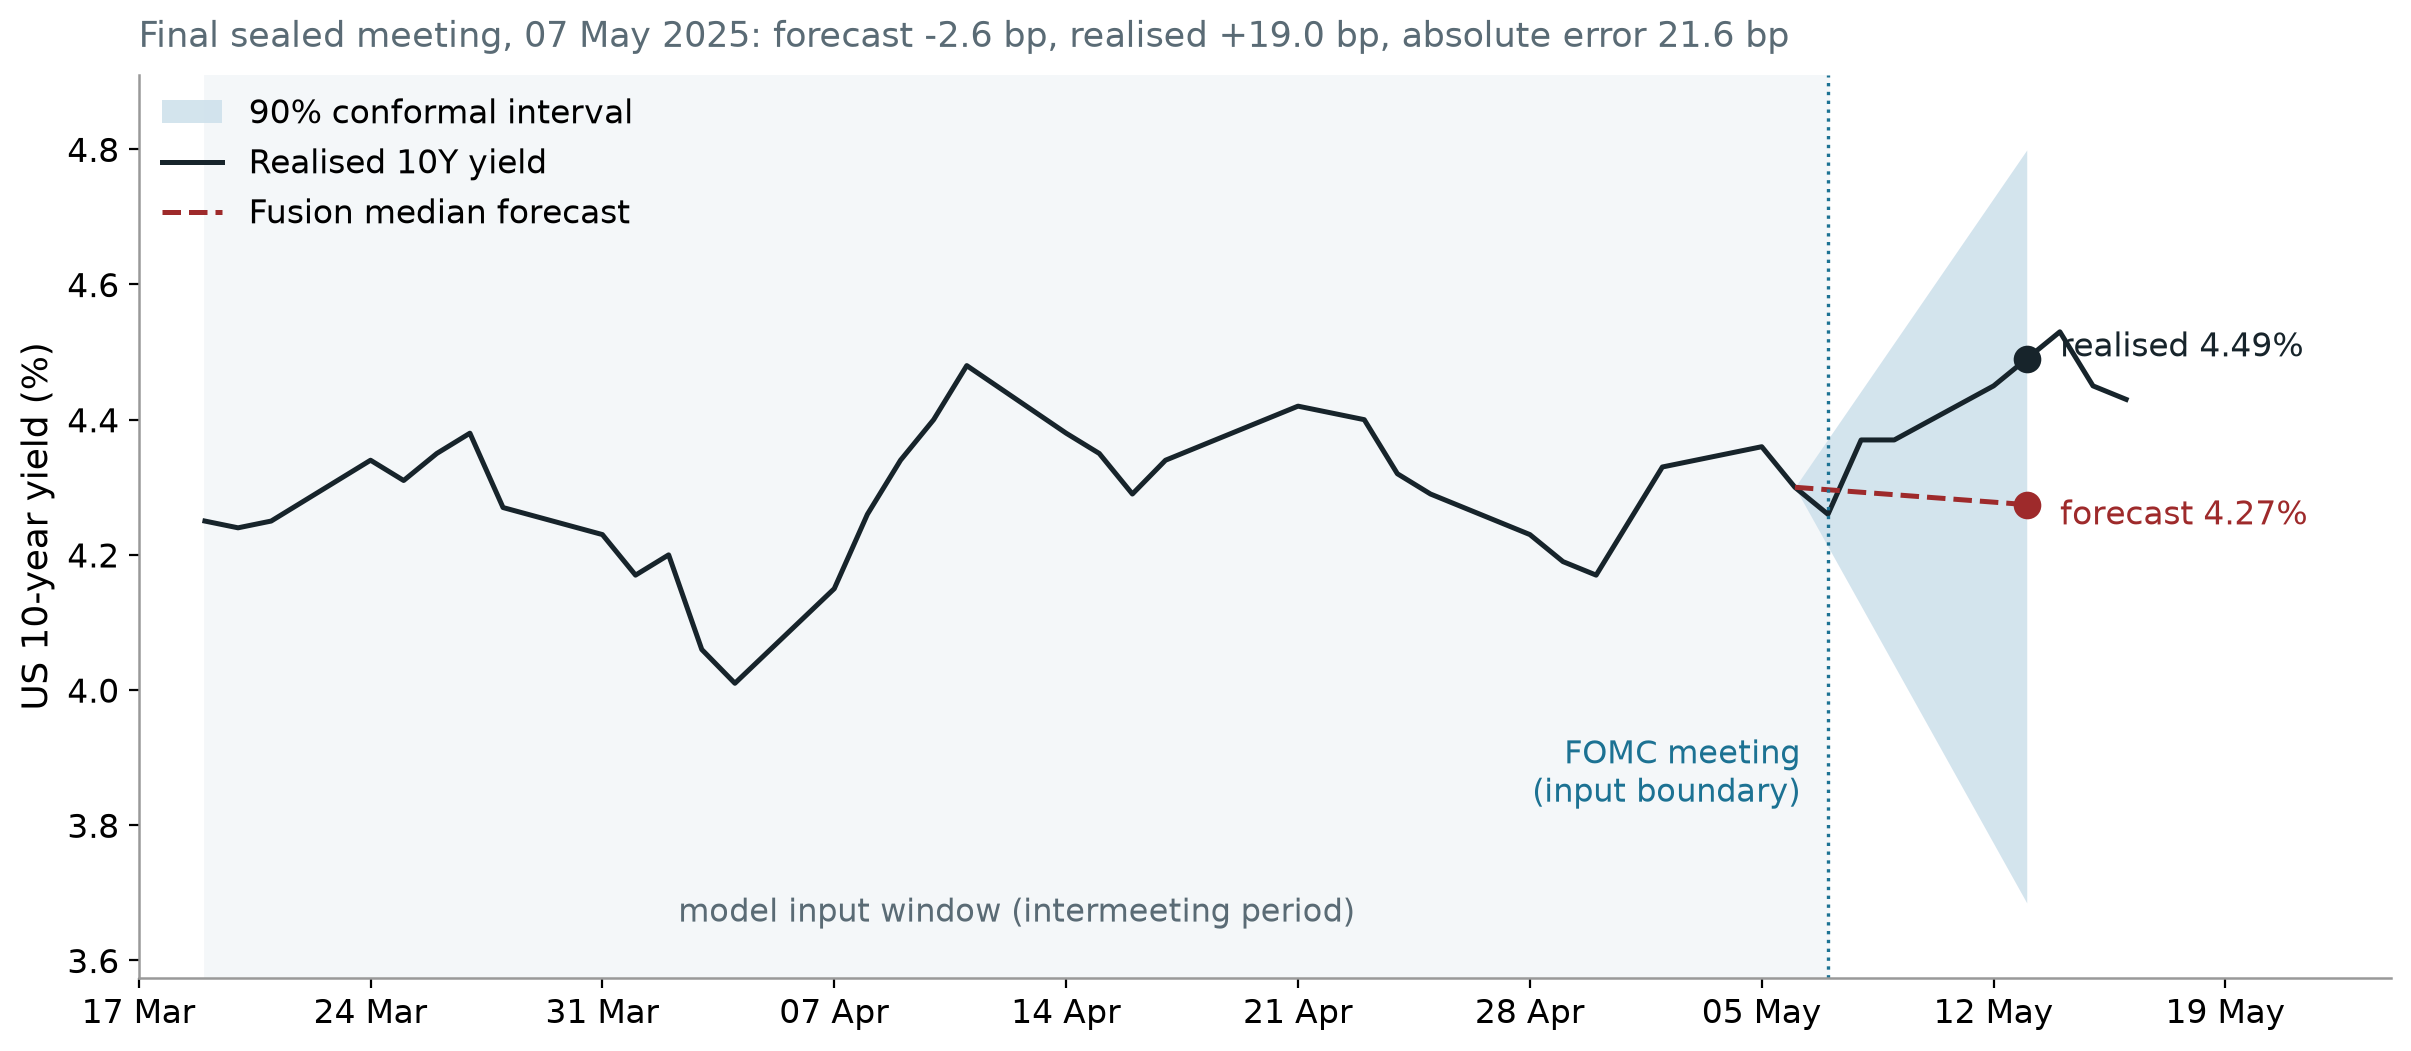

In [10]:
# Final sealed meeting: intermeeting input window, 5-day forecast and realisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BLUE, TEAL, RED, GREY, LIGHT, INK = "#065A82", "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

pred = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date", "target_date"],
).sort_values("meeting_date")
row, prev = pred.iloc[-1], pred.iloc[-2]

y = (pd.read_csv(paths.data / "raw" / "treasury_yields.csv", parse_dates=["date"])
       .set_index("date").DGS10.dropna())

anchor_date = y.index[y.index < row.meeting_date][-1]
anchor = y.loc[anchor_date]
window = y.loc[prev.meeting_date : row.target_date + pd.Timedelta(days=3)]

fc   = anchor + row.fusion_bp / 100
lo   = anchor + row.fusion_lower_bp / 100
hi   = anchor + row.fusion_upper_bp / 100
real = anchor + row.truth_bp / 100

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axvspan(prev.meeting_date, row.meeting_date, color="#F4F7F9", zorder=0)
ax.fill_between([anchor_date, row.target_date], [anchor, lo], [anchor, hi],
                color=LIGHT, alpha=0.9, lw=0, label="90% conformal interval")
ax.plot(window.index, window.values, color=INK, lw=1.8, label="Realised 10Y yield")
ax.plot([anchor_date, row.target_date], [anchor, fc], color=RED, lw=1.8, ls="--",
        label="Fusion median forecast")
ax.scatter([row.target_date], [fc], s=80, color=RED, zorder=4)
ax.scatter([row.target_date], [real], s=80, color=INK, zorder=4)
ax.axvline(row.meeting_date, color=TEAL, lw=1.2, ls=":")

lo_y, hi_y = min(lo, window.min()), max(hi, window.max())
pad = (hi_y - lo_y) * 0.10
ax.set_ylim(lo_y - pad, hi_y + pad)

ax.annotate("FOMC meeting\n(input boundary)", xy=(row.meeting_date, lo_y + pad * 1.2),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
            fontsize=11.5, color=TEAL)
ax.annotate(f"forecast {fc:.2f}%", xy=(row.target_date, fc), xytext=(12, -4),
            textcoords="offset points", fontsize=12, color=RED, va="center")
ax.annotate(f"realised {real:.2f}%", xy=(row.target_date, real), xytext=(12, 4),
            textcoords="offset points", fontsize=12, color=INK, va="center")
ax.text(prev.meeting_date + (row.meeting_date - prev.meeting_date) / 2,
        lo_y - pad * 0.35, "model input window (intermeeting period)",
        ha="center", va="bottom", fontsize=11.5, color=GREY)

ax.set_ylabel("US 10-year yield (%)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(prev.meeting_date - pd.Timedelta(days=2),
            row.target_date + pd.Timedelta(days=11))
ax.legend(frameon=False, loc="upper left", ncol=1, handlelength=1.8, borderpad=0.2)

err = abs(row.truth_bp - row.fusion_bp)
ax.set_title(f"Final sealed meeting, {row.meeting_date:%d %B %Y}: forecast "
             f"{row.fusion_bp:+.1f} bp, realised {row.truth_bp:+.1f} bp, "
             f"absolute error {err:.1f} bp",
             loc="left", color=GREY, fontsize=12.5, pad=10)
fig.tight_layout(pad=0.4)
plt.show()

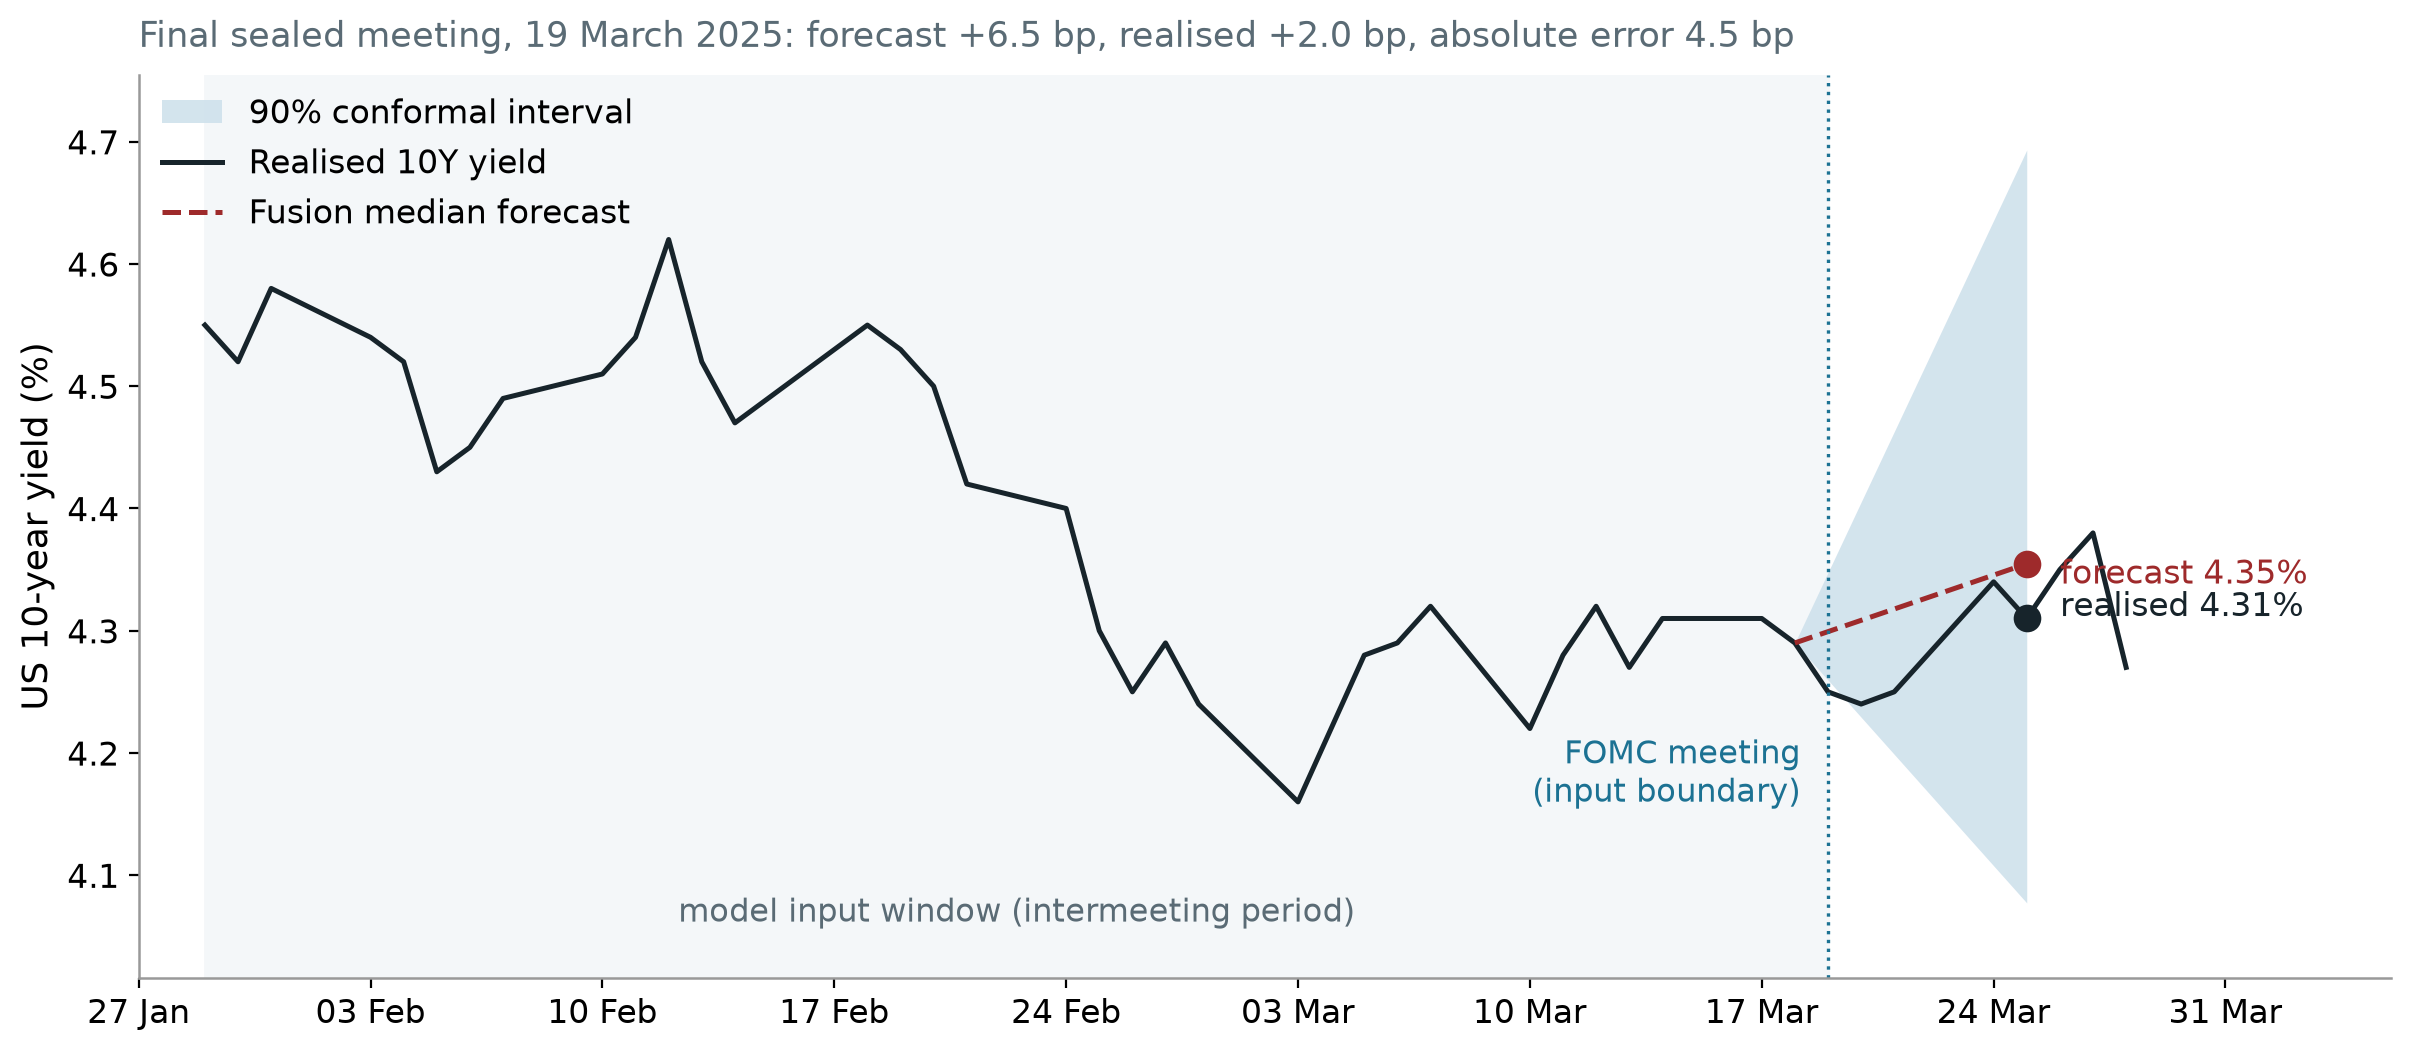

In [11]:
# Final sealed meeting: intermeeting input window, 5-day forecast and realisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BLUE, TEAL, RED, GREY, LIGHT, INK = "#065A82", "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

pred = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date", "target_date"],
).sort_values("meeting_date")
row, prev = pred.iloc[-2], pred.iloc[-3]

y = (pd.read_csv(paths.data / "raw" / "treasury_yields.csv", parse_dates=["date"])
       .set_index("date").DGS10.dropna())

anchor_date = y.index[y.index < row.meeting_date][-1]
anchor = y.loc[anchor_date]
window = y.loc[prev.meeting_date : row.target_date + pd.Timedelta(days=3)]

fc   = anchor + row.fusion_bp / 100
lo   = anchor + row.fusion_lower_bp / 100
hi   = anchor + row.fusion_upper_bp / 100
real = anchor + row.truth_bp / 100

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axvspan(prev.meeting_date, row.meeting_date, color="#F4F7F9", zorder=0)
ax.fill_between([anchor_date, row.target_date], [anchor, lo], [anchor, hi],
                color=LIGHT, alpha=0.9, lw=0, label="90% conformal interval")
ax.plot(window.index, window.values, color=INK, lw=1.8, label="Realised 10Y yield")
ax.plot([anchor_date, row.target_date], [anchor, fc], color=RED, lw=1.8, ls="--",
        label="Fusion median forecast")
ax.scatter([row.target_date], [fc], s=80, color=RED, zorder=4)
ax.scatter([row.target_date], [real], s=80, color=INK, zorder=4)
ax.axvline(row.meeting_date, color=TEAL, lw=1.2, ls=":")

lo_y, hi_y = min(lo, window.min()), max(hi, window.max())
pad = (hi_y - lo_y) * 0.10
ax.set_ylim(lo_y - pad, hi_y + pad)

ax.annotate("FOMC meeting\n(input boundary)", xy=(row.meeting_date, lo_y + pad * 1.2),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
            fontsize=11.5, color=TEAL)
ax.annotate(f"forecast {fc:.2f}%", xy=(row.target_date, fc), xytext=(12, -4),
            textcoords="offset points", fontsize=12, color=RED, va="center")
ax.annotate(f"realised {real:.2f}%", xy=(row.target_date, real), xytext=(12, 4),
            textcoords="offset points", fontsize=12, color=INK, va="center")
ax.text(prev.meeting_date + (row.meeting_date - prev.meeting_date) / 2,
        lo_y - pad * 0.35, "model input window (intermeeting period)",
        ha="center", va="bottom", fontsize=11.5, color=GREY)

ax.set_ylabel("US 10-year yield (%)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(prev.meeting_date - pd.Timedelta(days=2),
            row.target_date + pd.Timedelta(days=11))
ax.legend(frameon=False, loc="upper left", ncol=1, handlelength=1.8, borderpad=0.2)

err = abs(row.truth_bp - row.fusion_bp)
ax.set_title(f"Final sealed meeting, {row.meeting_date:%d %B %Y}: forecast "
             f"{row.fusion_bp:+.1f} bp, realised {row.truth_bp:+.1f} bp, "
             f"absolute error {err:.1f} bp",
             loc="left", color=GREY, fontsize=12.5, pad=10)
fig.tight_layout(pad=0.4)
plt.show()

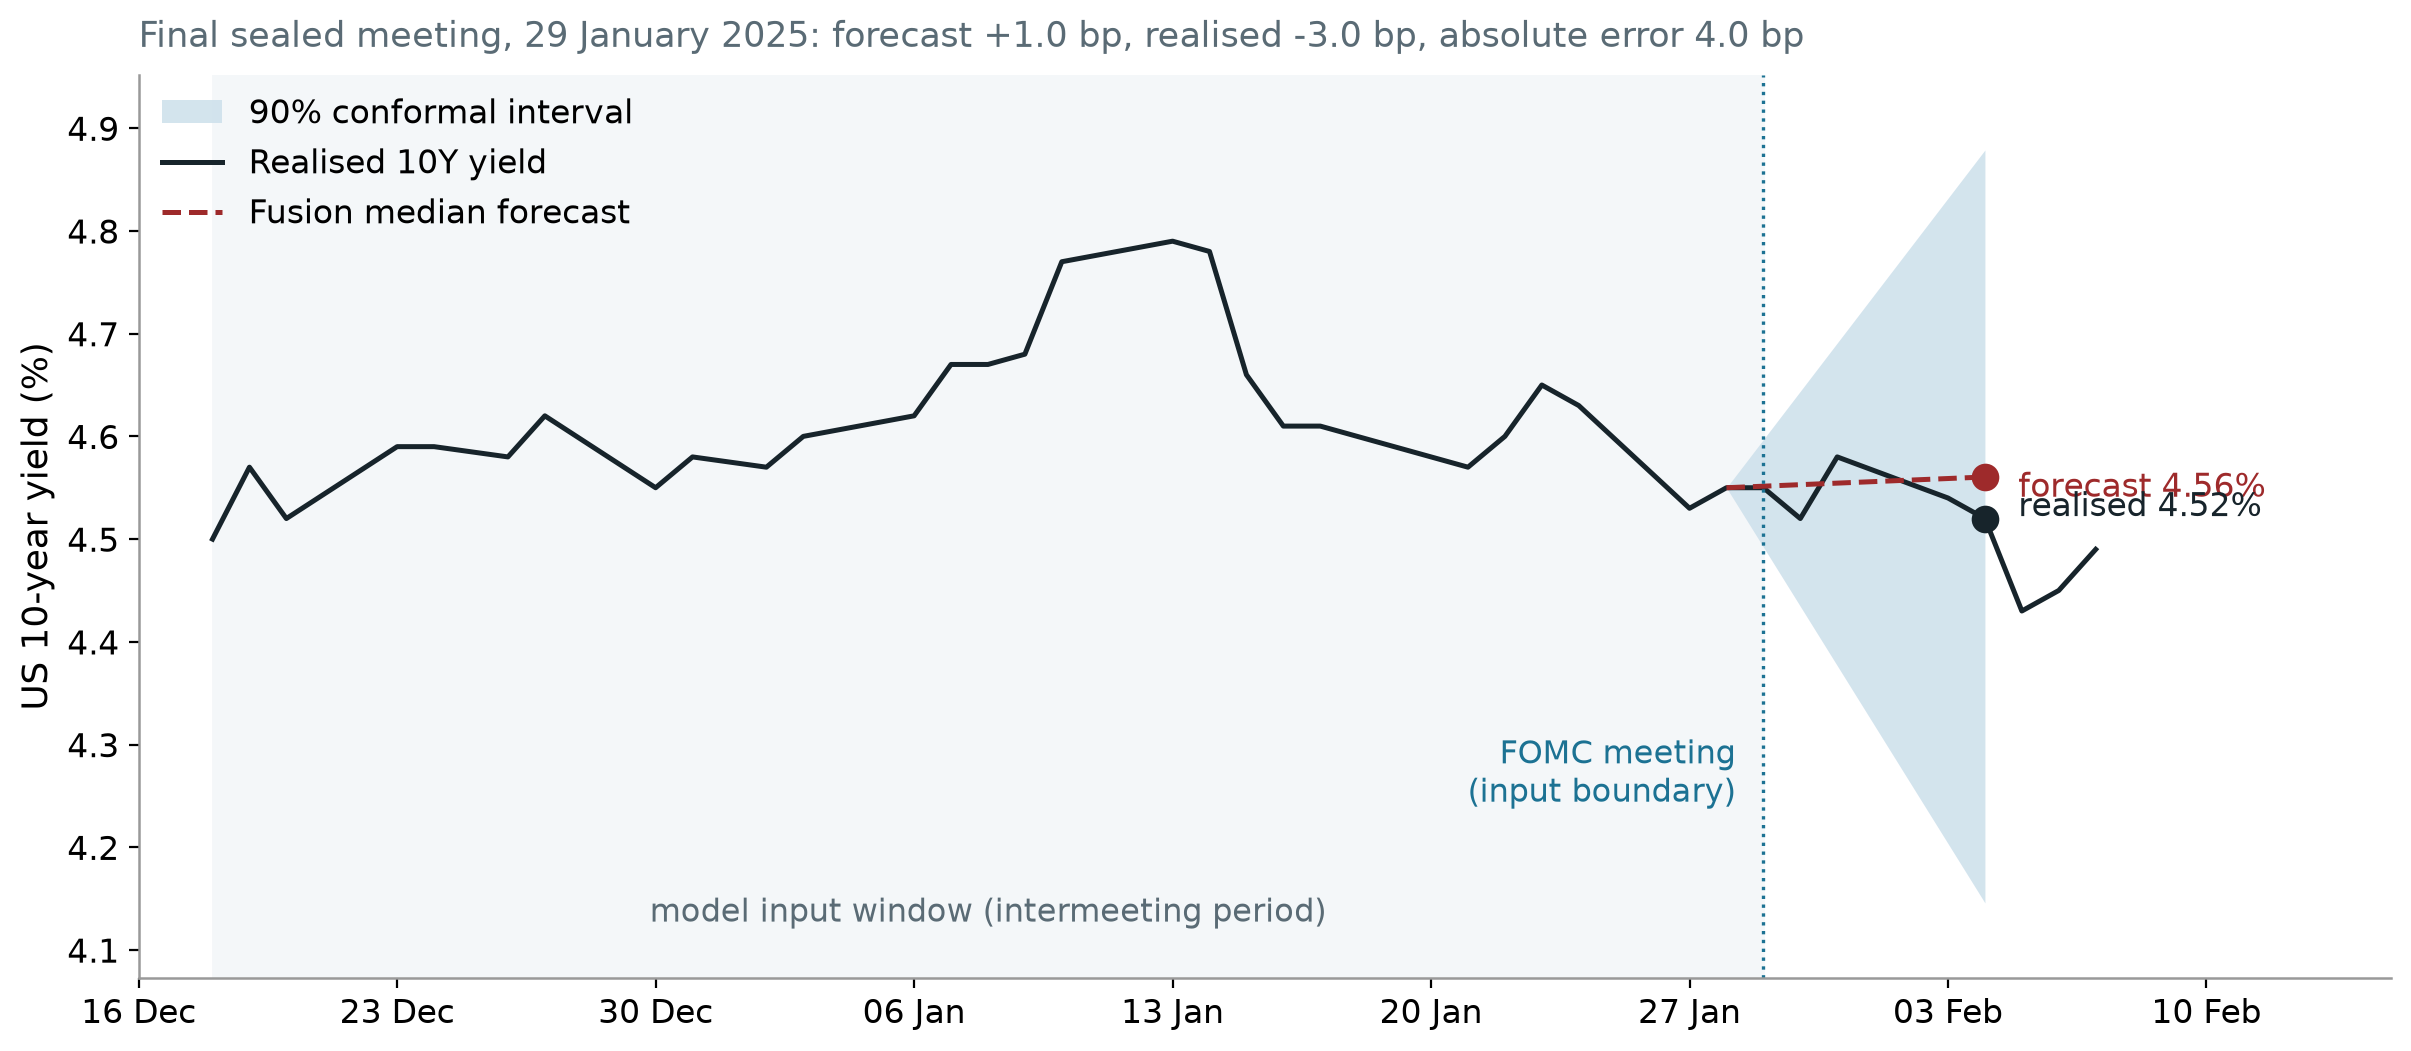

In [12]:
# Final sealed meeting: intermeeting input window, 5-day forecast and realisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BLUE, TEAL, RED, GREY, LIGHT, INK = "#065A82", "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

pred = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date", "target_date"],
).sort_values("meeting_date")
row, prev = pred.iloc[-3], pred.iloc[-4]

y = (pd.read_csv(paths.data / "raw" / "treasury_yields.csv", parse_dates=["date"])
       .set_index("date").DGS10.dropna())

anchor_date = y.index[y.index < row.meeting_date][-1]
anchor = y.loc[anchor_date]
window = y.loc[prev.meeting_date : row.target_date + pd.Timedelta(days=3)]

fc   = anchor + row.fusion_bp / 100
lo   = anchor + row.fusion_lower_bp / 100
hi   = anchor + row.fusion_upper_bp / 100
real = anchor + row.truth_bp / 100

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axvspan(prev.meeting_date, row.meeting_date, color="#F4F7F9", zorder=0)
ax.fill_between([anchor_date, row.target_date], [anchor, lo], [anchor, hi],
                color=LIGHT, alpha=0.9, lw=0, label="90% conformal interval")
ax.plot(window.index, window.values, color=INK, lw=1.8, label="Realised 10Y yield")
ax.plot([anchor_date, row.target_date], [anchor, fc], color=RED, lw=1.8, ls="--",
        label="Fusion median forecast")
ax.scatter([row.target_date], [fc], s=80, color=RED, zorder=4)
ax.scatter([row.target_date], [real], s=80, color=INK, zorder=4)
ax.axvline(row.meeting_date, color=TEAL, lw=1.2, ls=":")

lo_y, hi_y = min(lo, window.min()), max(hi, window.max())
pad = (hi_y - lo_y) * 0.10
ax.set_ylim(lo_y - pad, hi_y + pad)

ax.annotate("FOMC meeting\n(input boundary)", xy=(row.meeting_date, lo_y + pad * 1.2),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
            fontsize=11.5, color=TEAL)
ax.annotate(f"forecast {fc:.2f}%", xy=(row.target_date, fc), xytext=(12, -4),
            textcoords="offset points", fontsize=12, color=RED, va="center")
ax.annotate(f"realised {real:.2f}%", xy=(row.target_date, real), xytext=(12, 4),
            textcoords="offset points", fontsize=12, color=INK, va="center")
ax.text(prev.meeting_date + (row.meeting_date - prev.meeting_date) / 2,
        lo_y - pad * 0.35, "model input window (intermeeting period)",
        ha="center", va="bottom", fontsize=11.5, color=GREY)

ax.set_ylabel("US 10-year yield (%)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(prev.meeting_date - pd.Timedelta(days=2),
            row.target_date + pd.Timedelta(days=11))
ax.legend(frameon=False, loc="upper left", ncol=1, handlelength=1.8, borderpad=0.2)

err = abs(row.truth_bp - row.fusion_bp)
ax.set_title(f"Final sealed meeting, {row.meeting_date:%d %B %Y}: forecast "
             f"{row.fusion_bp:+.1f} bp, realised {row.truth_bp:+.1f} bp, "
             f"absolute error {err:.1f} bp",
             loc="left", color=GREY, fontsize=12.5, pad=10)
fig.tight_layout(pad=0.4)
plt.show()

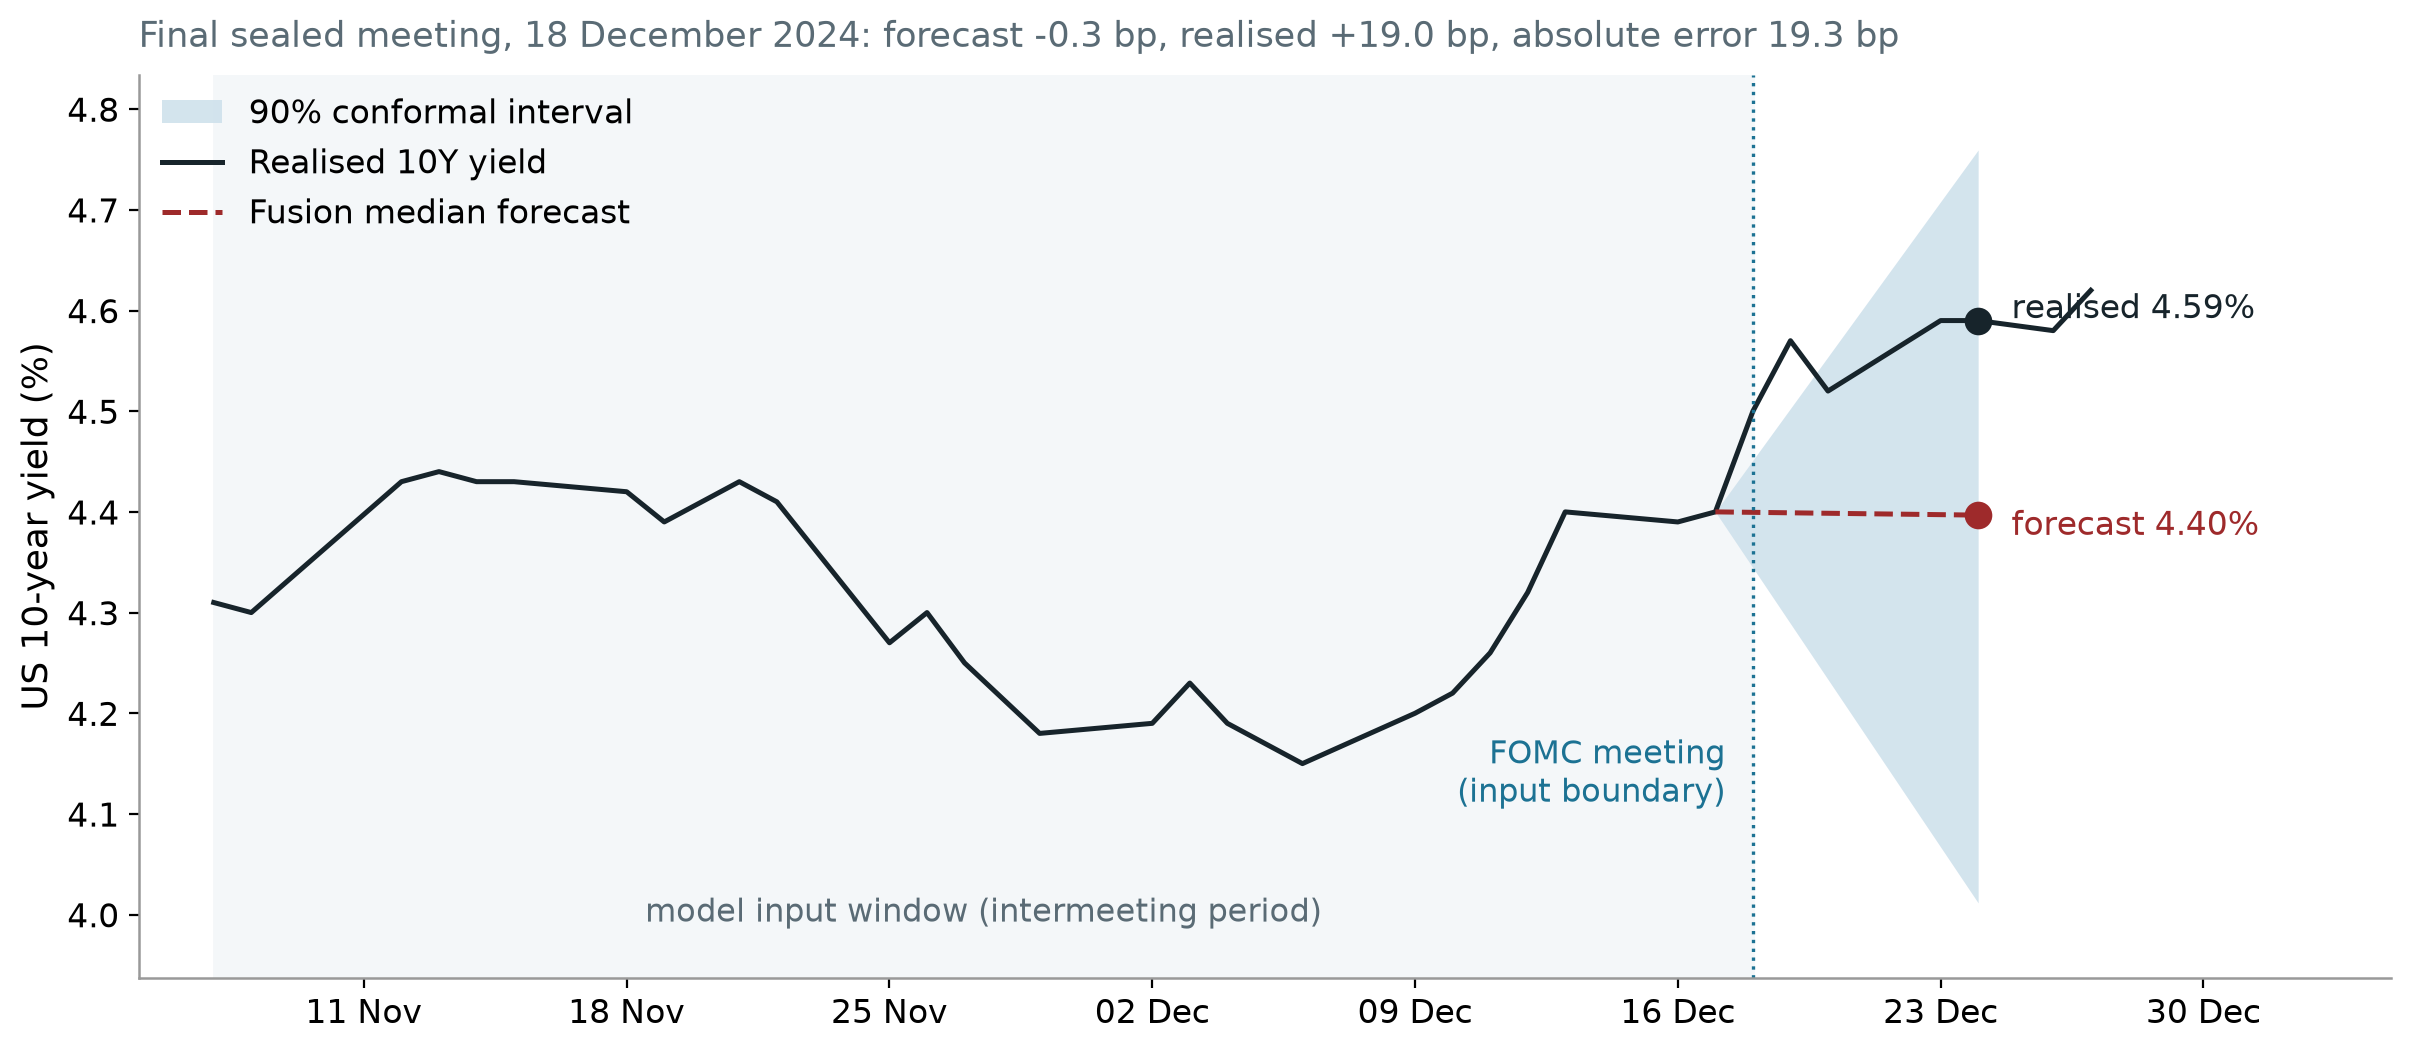

In [13]:
# Final sealed meeting: intermeeting input window, 5-day forecast and realisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BLUE, TEAL, RED, GREY, LIGHT, INK = "#065A82", "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

pred = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date", "target_date"],
).sort_values("meeting_date")
row, prev = pred.iloc[-4], pred.iloc[-5]

y = (pd.read_csv(paths.data / "raw" / "treasury_yields.csv", parse_dates=["date"])
       .set_index("date").DGS10.dropna())

anchor_date = y.index[y.index < row.meeting_date][-1]
anchor = y.loc[anchor_date]
window = y.loc[prev.meeting_date : row.target_date + pd.Timedelta(days=3)]

fc   = anchor + row.fusion_bp / 100
lo   = anchor + row.fusion_lower_bp / 100
hi   = anchor + row.fusion_upper_bp / 100
real = anchor + row.truth_bp / 100

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axvspan(prev.meeting_date, row.meeting_date, color="#F4F7F9", zorder=0)
ax.fill_between([anchor_date, row.target_date], [anchor, lo], [anchor, hi],
                color=LIGHT, alpha=0.9, lw=0, label="90% conformal interval")
ax.plot(window.index, window.values, color=INK, lw=1.8, label="Realised 10Y yield")
ax.plot([anchor_date, row.target_date], [anchor, fc], color=RED, lw=1.8, ls="--",
        label="Fusion median forecast")
ax.scatter([row.target_date], [fc], s=80, color=RED, zorder=4)
ax.scatter([row.target_date], [real], s=80, color=INK, zorder=4)
ax.axvline(row.meeting_date, color=TEAL, lw=1.2, ls=":")

lo_y, hi_y = min(lo, window.min()), max(hi, window.max())
pad = (hi_y - lo_y) * 0.10
ax.set_ylim(lo_y - pad, hi_y + pad)

ax.annotate("FOMC meeting\n(input boundary)", xy=(row.meeting_date, lo_y + pad * 1.2),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
            fontsize=11.5, color=TEAL)
ax.annotate(f"forecast {fc:.2f}%", xy=(row.target_date, fc), xytext=(12, -4),
            textcoords="offset points", fontsize=12, color=RED, va="center")
ax.annotate(f"realised {real:.2f}%", xy=(row.target_date, real), xytext=(12, 4),
            textcoords="offset points", fontsize=12, color=INK, va="center")
ax.text(prev.meeting_date + (row.meeting_date - prev.meeting_date) / 2,
        lo_y - pad * 0.35, "model input window (intermeeting period)",
        ha="center", va="bottom", fontsize=11.5, color=GREY)

ax.set_ylabel("US 10-year yield (%)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(prev.meeting_date - pd.Timedelta(days=2),
            row.target_date + pd.Timedelta(days=11))
ax.legend(frameon=False, loc="upper left", ncol=1, handlelength=1.8, borderpad=0.2)

err = abs(row.truth_bp - row.fusion_bp)
ax.set_title(f"Final sealed meeting, {row.meeting_date:%d %B %Y}: forecast "
             f"{row.fusion_bp:+.1f} bp, realised {row.truth_bp:+.1f} bp, "
             f"absolute error {err:.1f} bp",
             loc="left", color=GREY, fontsize=12.5, pad=10)
fig.tight_layout(pad=0.4)
plt.show()

In [14]:
# Last four sealed meetings: forecast, realisation and absolute error
last_four = pred.tail(4).copy()
last_four["abs_error_bp"] = (last_four.truth_bp - last_four.fusion_bp).abs()

last_four_table = pd.DataFrame({
    "Meeting": last_four.meeting_date.dt.strftime("%d %b %Y"),
    "Forecast (bp)": last_four.fusion_bp.round(1),
    "Realised (bp)": last_four.truth_bp.round(1),
    "Absolute error (bp)": last_four.abs_error_bp.round(1),
}).iloc[::-1].reset_index(drop=True)

display(last_four_table)

print(f"Pooled MAE across all {len(pred)} sealed meetings: "
      f"{(pred.truth_bp - pred.fusion_bp).abs().mean():.3f} bp")

,Meeting,Forecast (bp),Realised (bp),Absolute error (bp)
0,07 May 2025,-2.6,19.0,21.6
1,19 Mar 2025,6.5,2.0,4.5
2,29 Jan 2025,1.0,-3.0,4.0
3,18 Dec 2024,-0.3,19.0,19.3


Pooled MAE across all 178 sealed meetings: 13.331 bp


In [15]:
# Table 5: Pooled sealed out-of-sample performance across 178 FOMC meetings
display_names = {
    "price_only":    "Price-only",
    "rate_only":     "Price plus rate",
    "shuffled_text": "Shuffled text",
    "fusion":        "Aligned fusion",
}

table5 = pd.DataFrame([
    {
        "Model": label,
        "MAE (bp)": round(summary["models"][key]["mae_bp"], 3),
        "RMSE (bp)": round(summary["models"][key]["rmse_bp"], 3),
        "Balanced accuracy": round(summary["models"][key]["balanced_accuracy"], 3),
        "Macro F1": round(summary["models"][key]["macro_f1"], 3),
    }
    for key, label in display_names.items()
])

display(table5)
print(f"Pooled across {summary['n_oos']} sealed FOMC meetings.")

,Model,MAE (bp),RMSE (bp),Balanced accuracy,Macro F1
0,Price-only,12.154,16.574,0.297,0.297
1,Price plus rate,13.191,16.477,0.301,0.302
2,Shuffled text,13.262,17.404,0.310,0.310
3,Aligned fusion,13.331,17.341,0.288,0.285


Pooled across 178 sealed FOMC meetings.


## Holdout Releasing - Prediction

In [16]:
# Table 5 format, applied to the sealed final-year holdout
import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score

holdout = pd.read_csv(
    paths.outputs / "predictions" / "final_holdout_predictions.csv",
    parse_dates=["meeting_date", "target_date"],
).sort_values("meeting_date").reset_index(drop=True)

display_names = {
    "price_only":    "Price-only",
    "rate_only":     "Price plus rate",
    "shuffled_text": "Shuffled text",
    "fusion":        "Aligned fusion",
}

rows = []
for key, label in display_names.items():
    error = holdout.truth_bp - holdout[f"{key}_bp"]
    rows.append({
        "Model": label,
        "MAE (bp)": round(np.abs(error).mean(), 3),
        "RMSE (bp)": round(np.sqrt((error ** 2).mean()), 3),
        "Balanced accuracy": round(
            balanced_accuracy_score(holdout.true_class, holdout[f"{key}_class"]), 3),
        "Macro F1": round(
            f1_score(holdout.true_class, holdout[f"{key}_class"], average="macro"), 3),
    })

holdout_table = pd.DataFrame(rows)
display(holdout_table)

coverage = ((holdout.truth_bp >= holdout.fusion_lower_bp)
            & (holdout.truth_bp <= holdout.fusion_upper_bp)).mean()
width = (holdout.fusion_upper_bp - holdout.fusion_lower_bp).mean()
print(f"Held-out final year: {len(holdout)} FOMC meetings, "
      f"{holdout.meeting_date.min():%d %b %Y} to {holdout.meeting_date.max():%d %b %Y}")
print(f"Fusion interval coverage {coverage:.3f}, mean width {width:.2f} bp")

,Model,MAE (bp),RMSE (bp),Balanced accuracy,Macro F1
0,Price-only,7.964,9.401,0.289,0.231
1,Price plus rate,10.710,13.050,0.333,0.200
2,Shuffled text,10.343,12.740,0.356,0.339
3,Aligned fusion,10.465,12.586,0.356,0.339


Held-out final year: 9 FOMC meetings, 18 Jun 2025 to 17 Jun 2026
Fusion interval coverage 0.889, mean width 51.74 bp


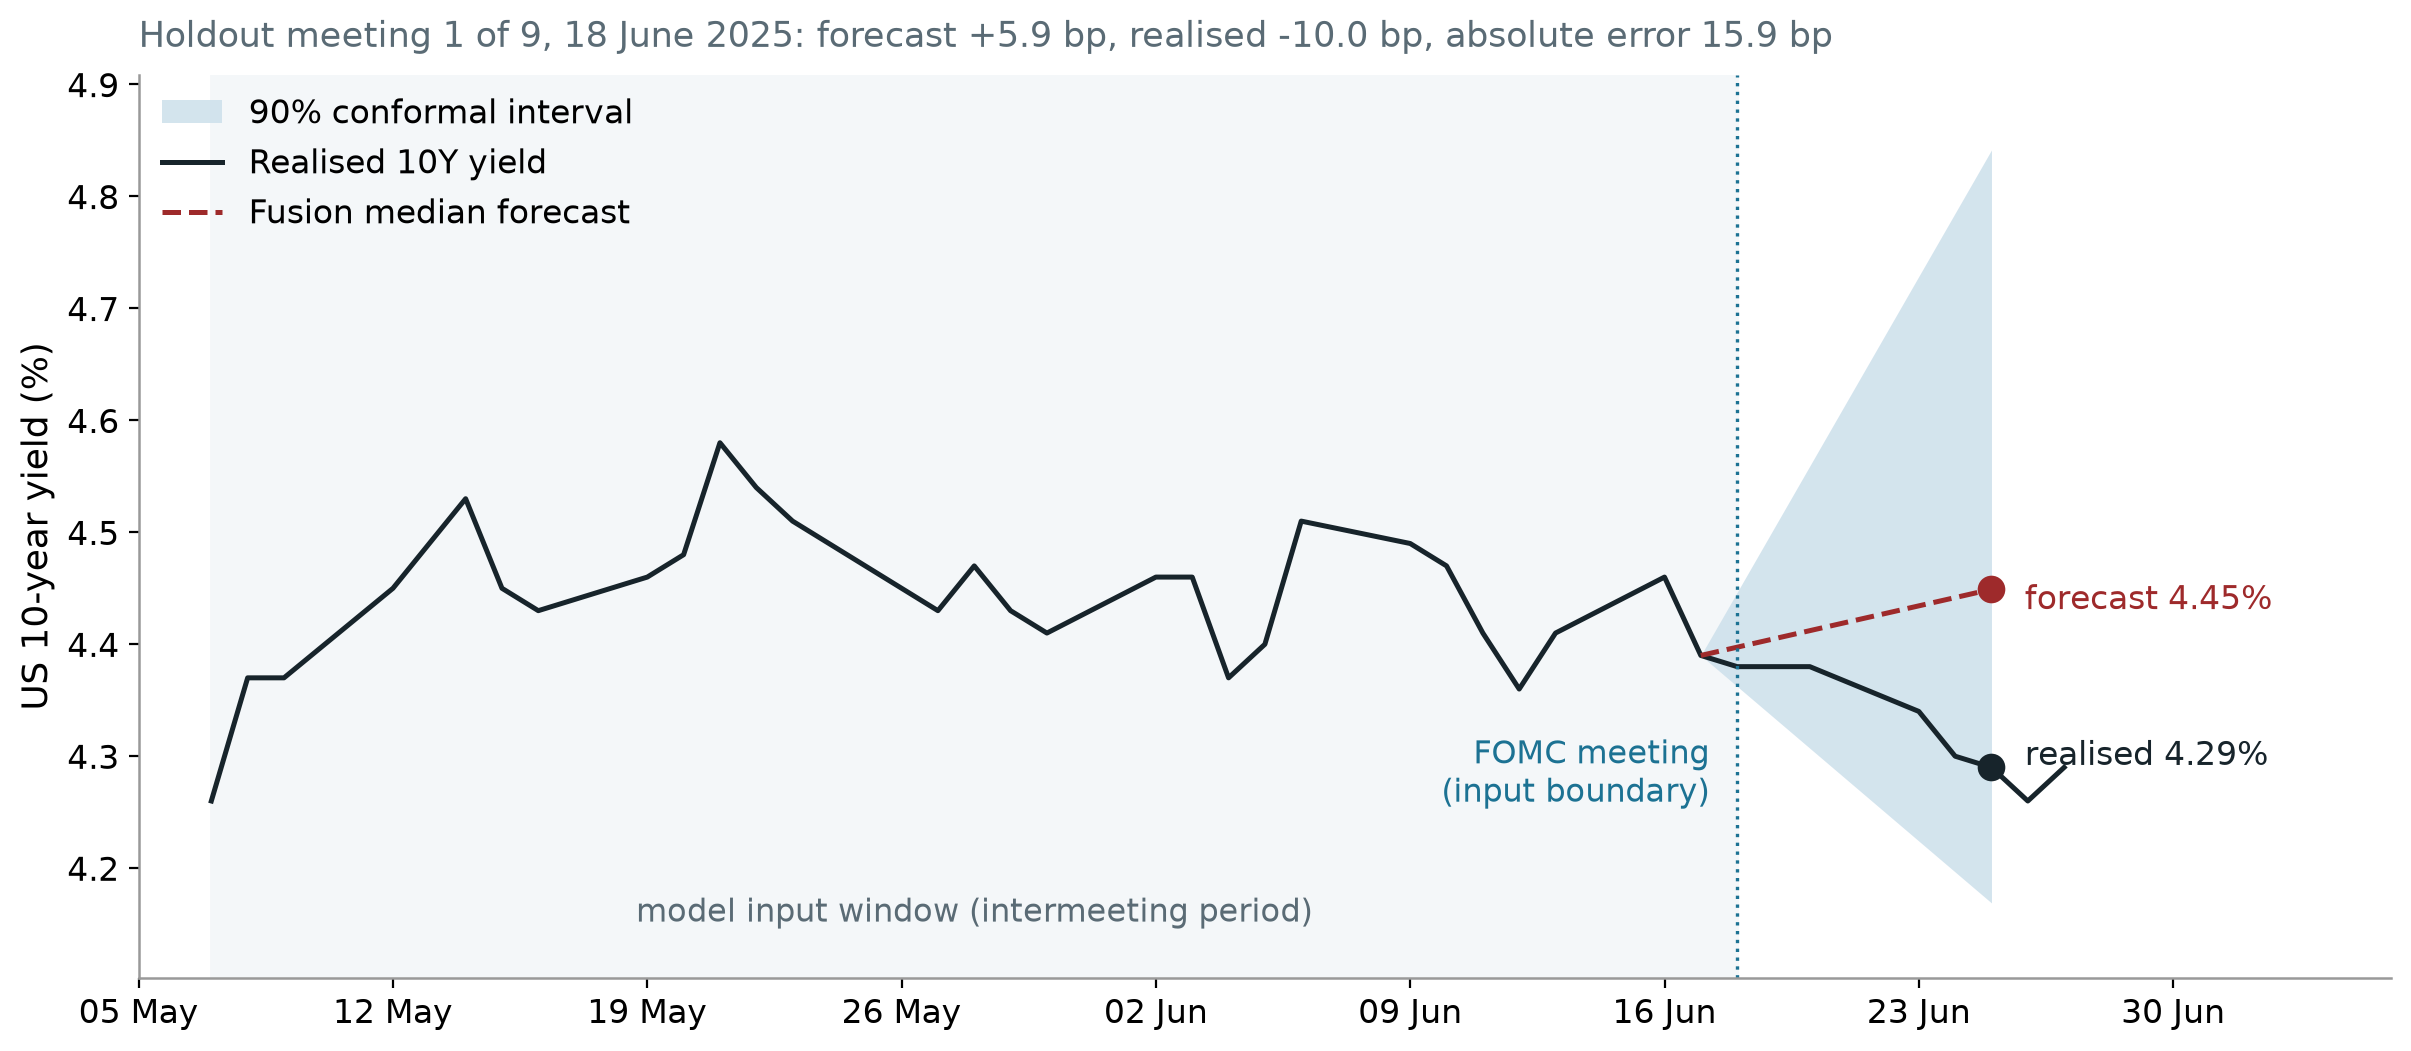

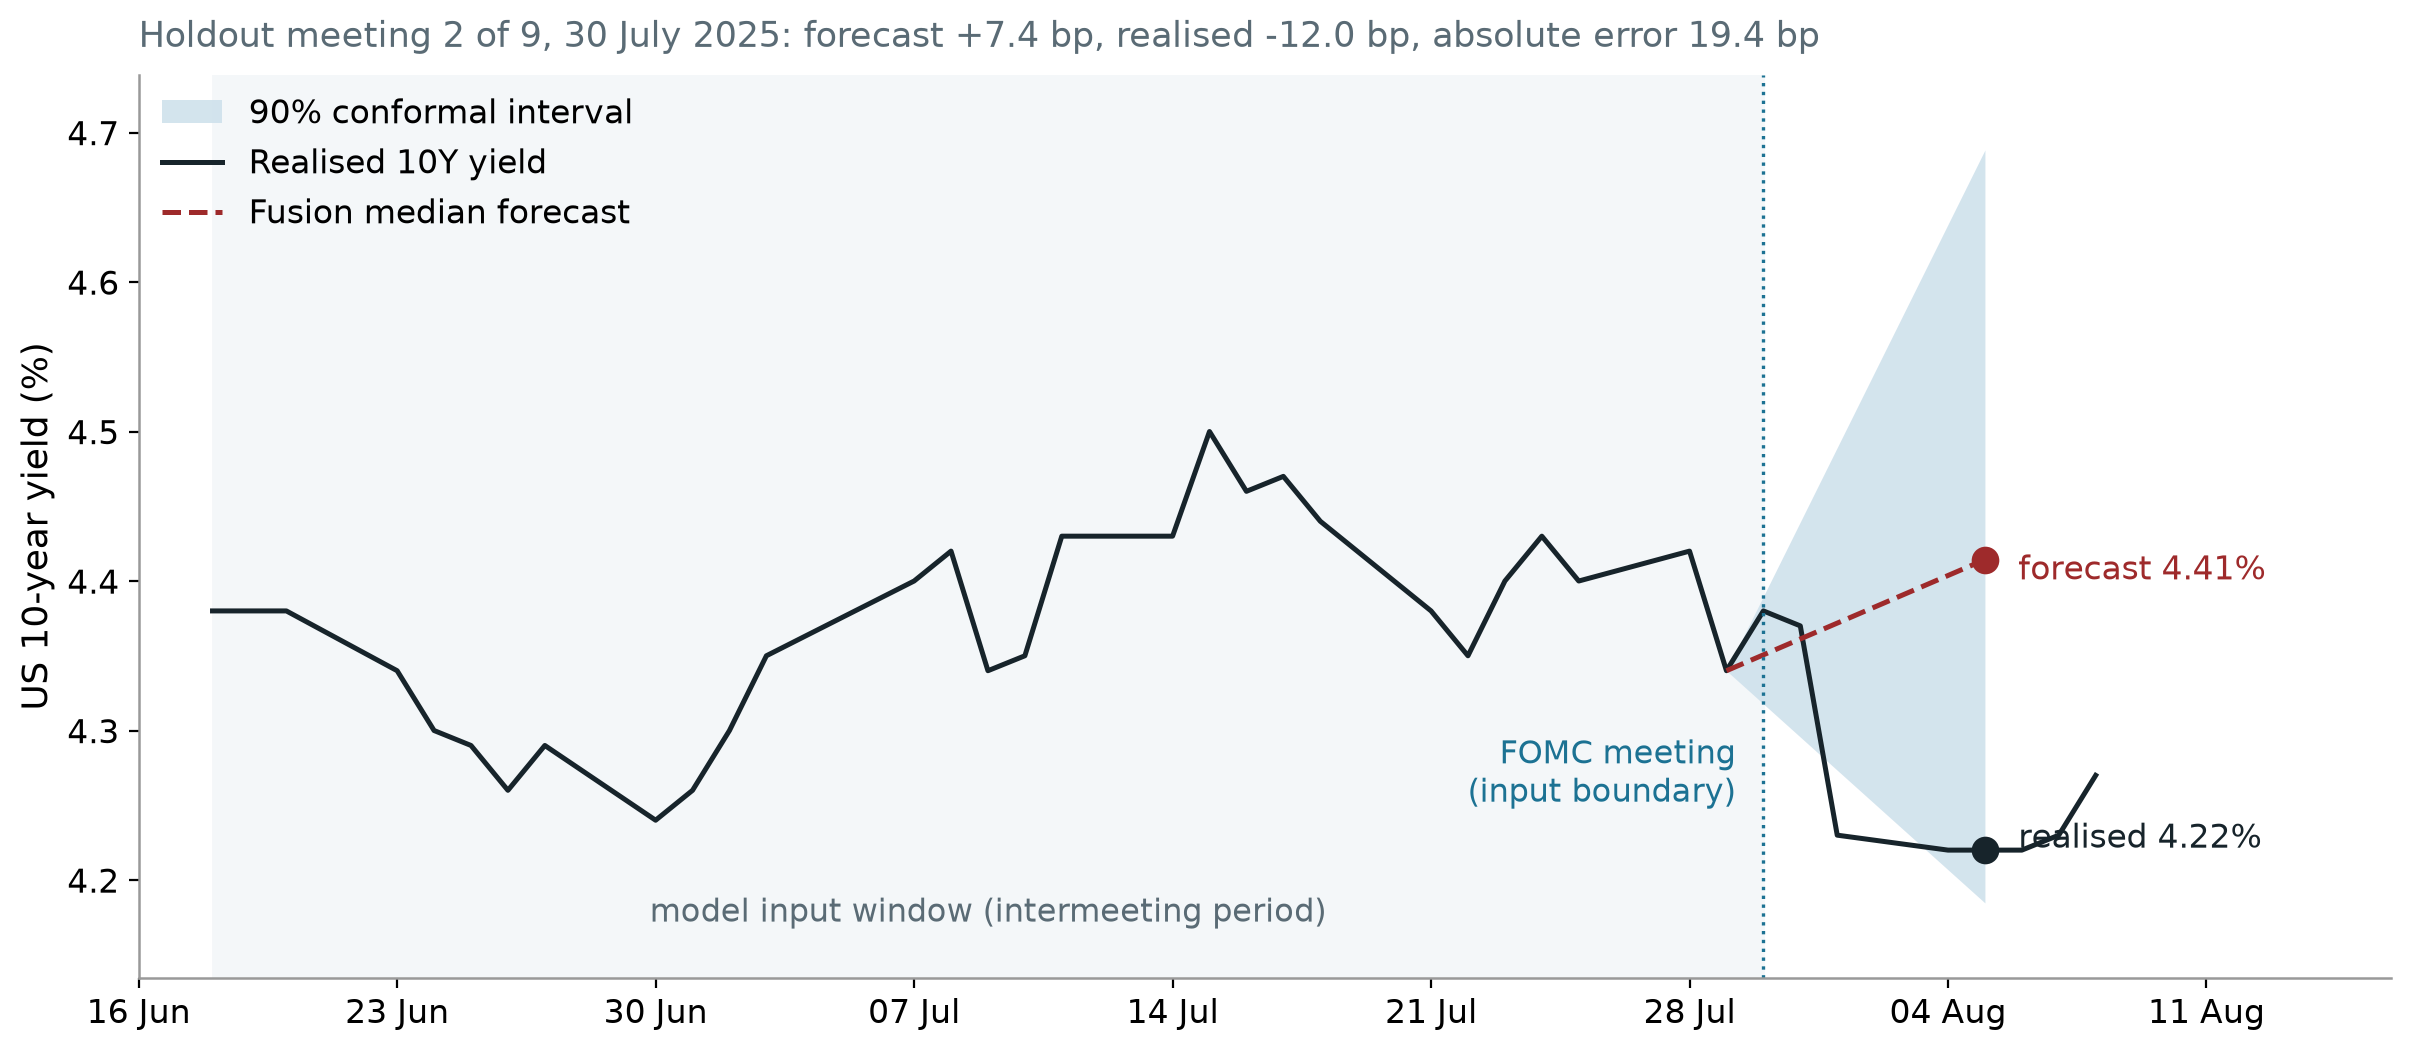

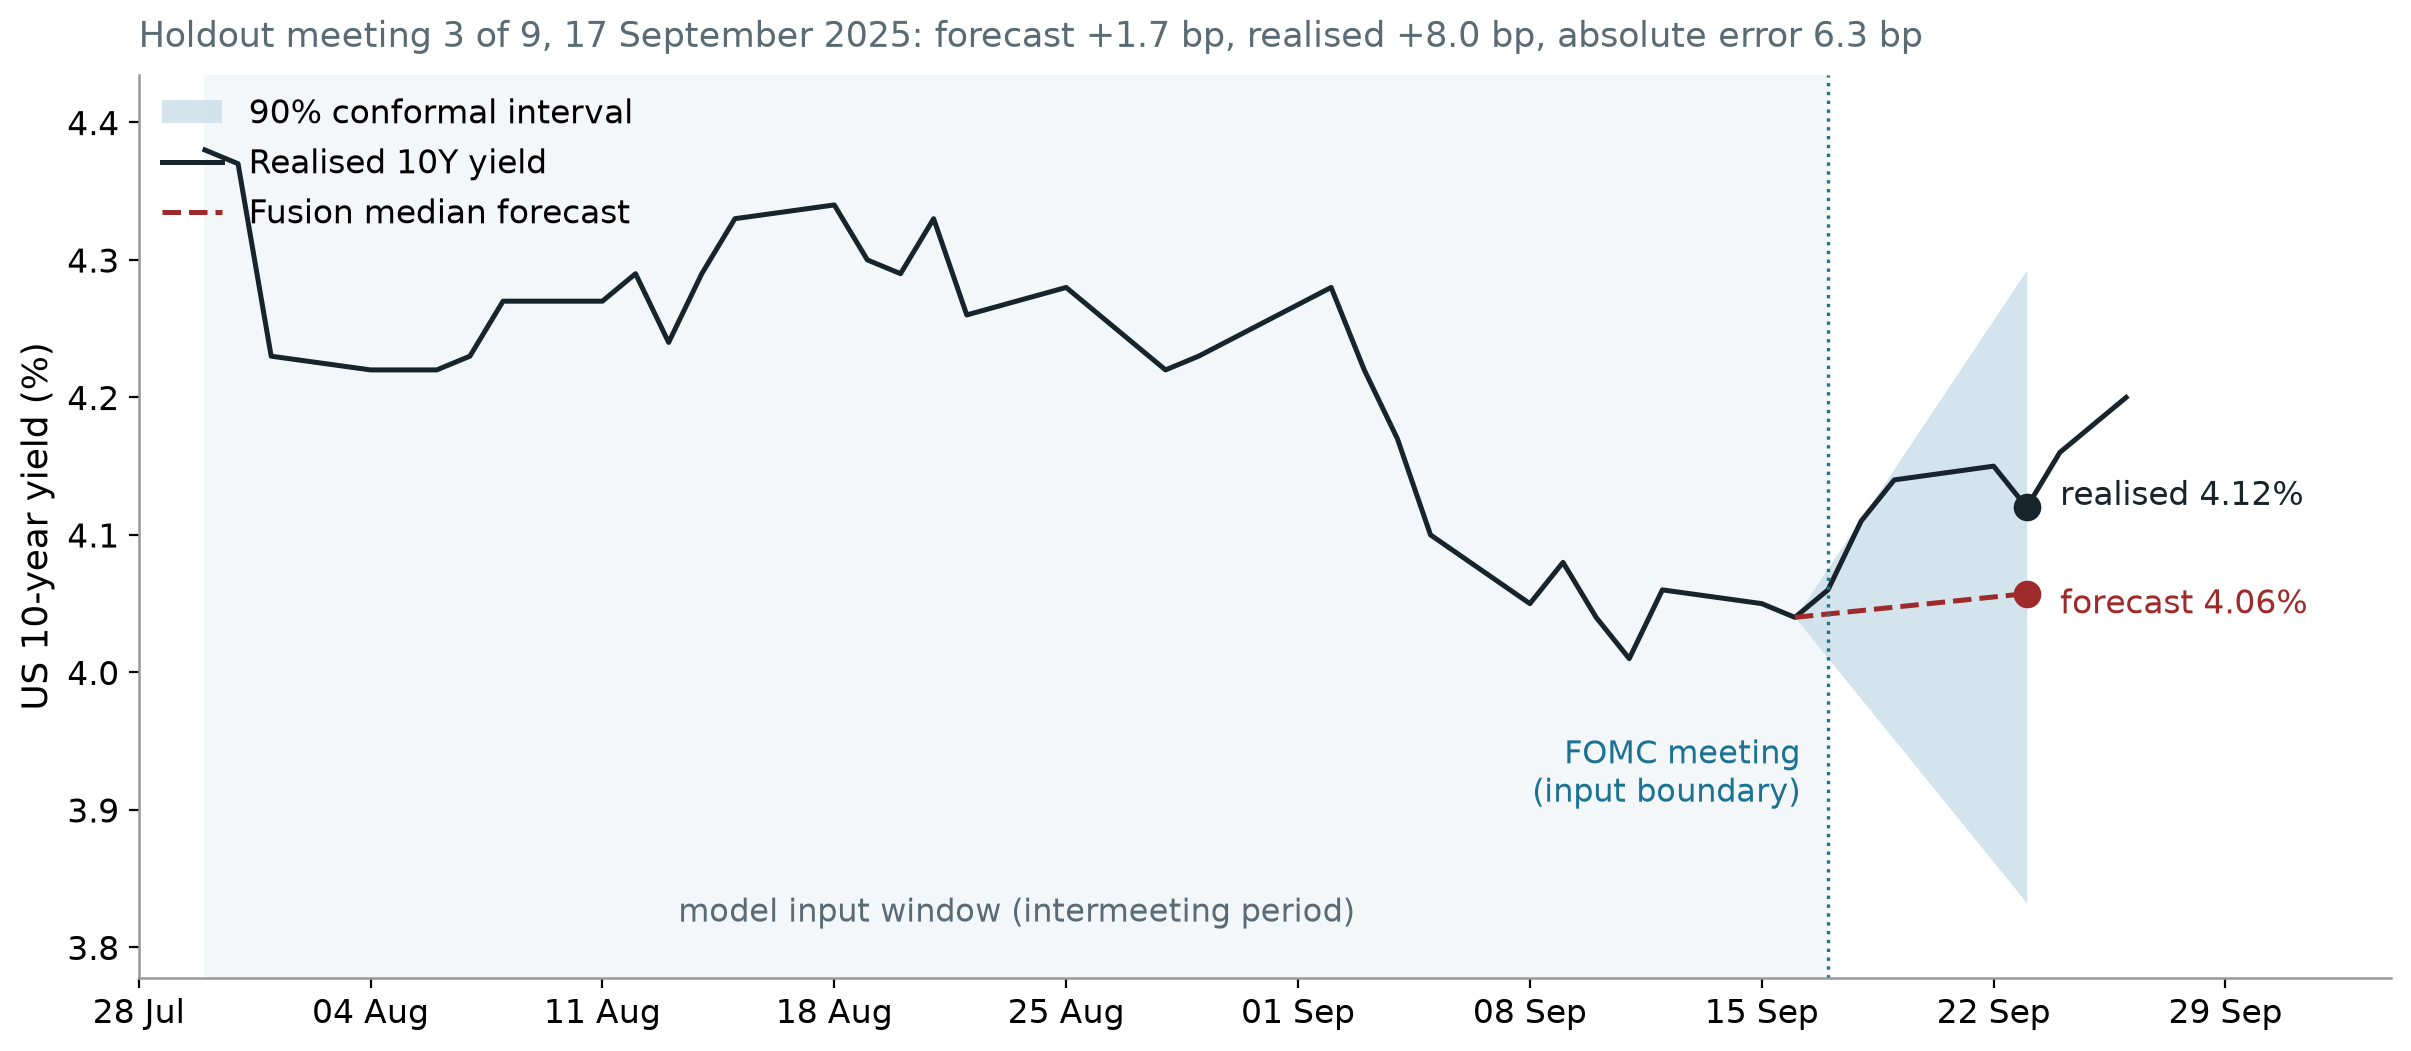

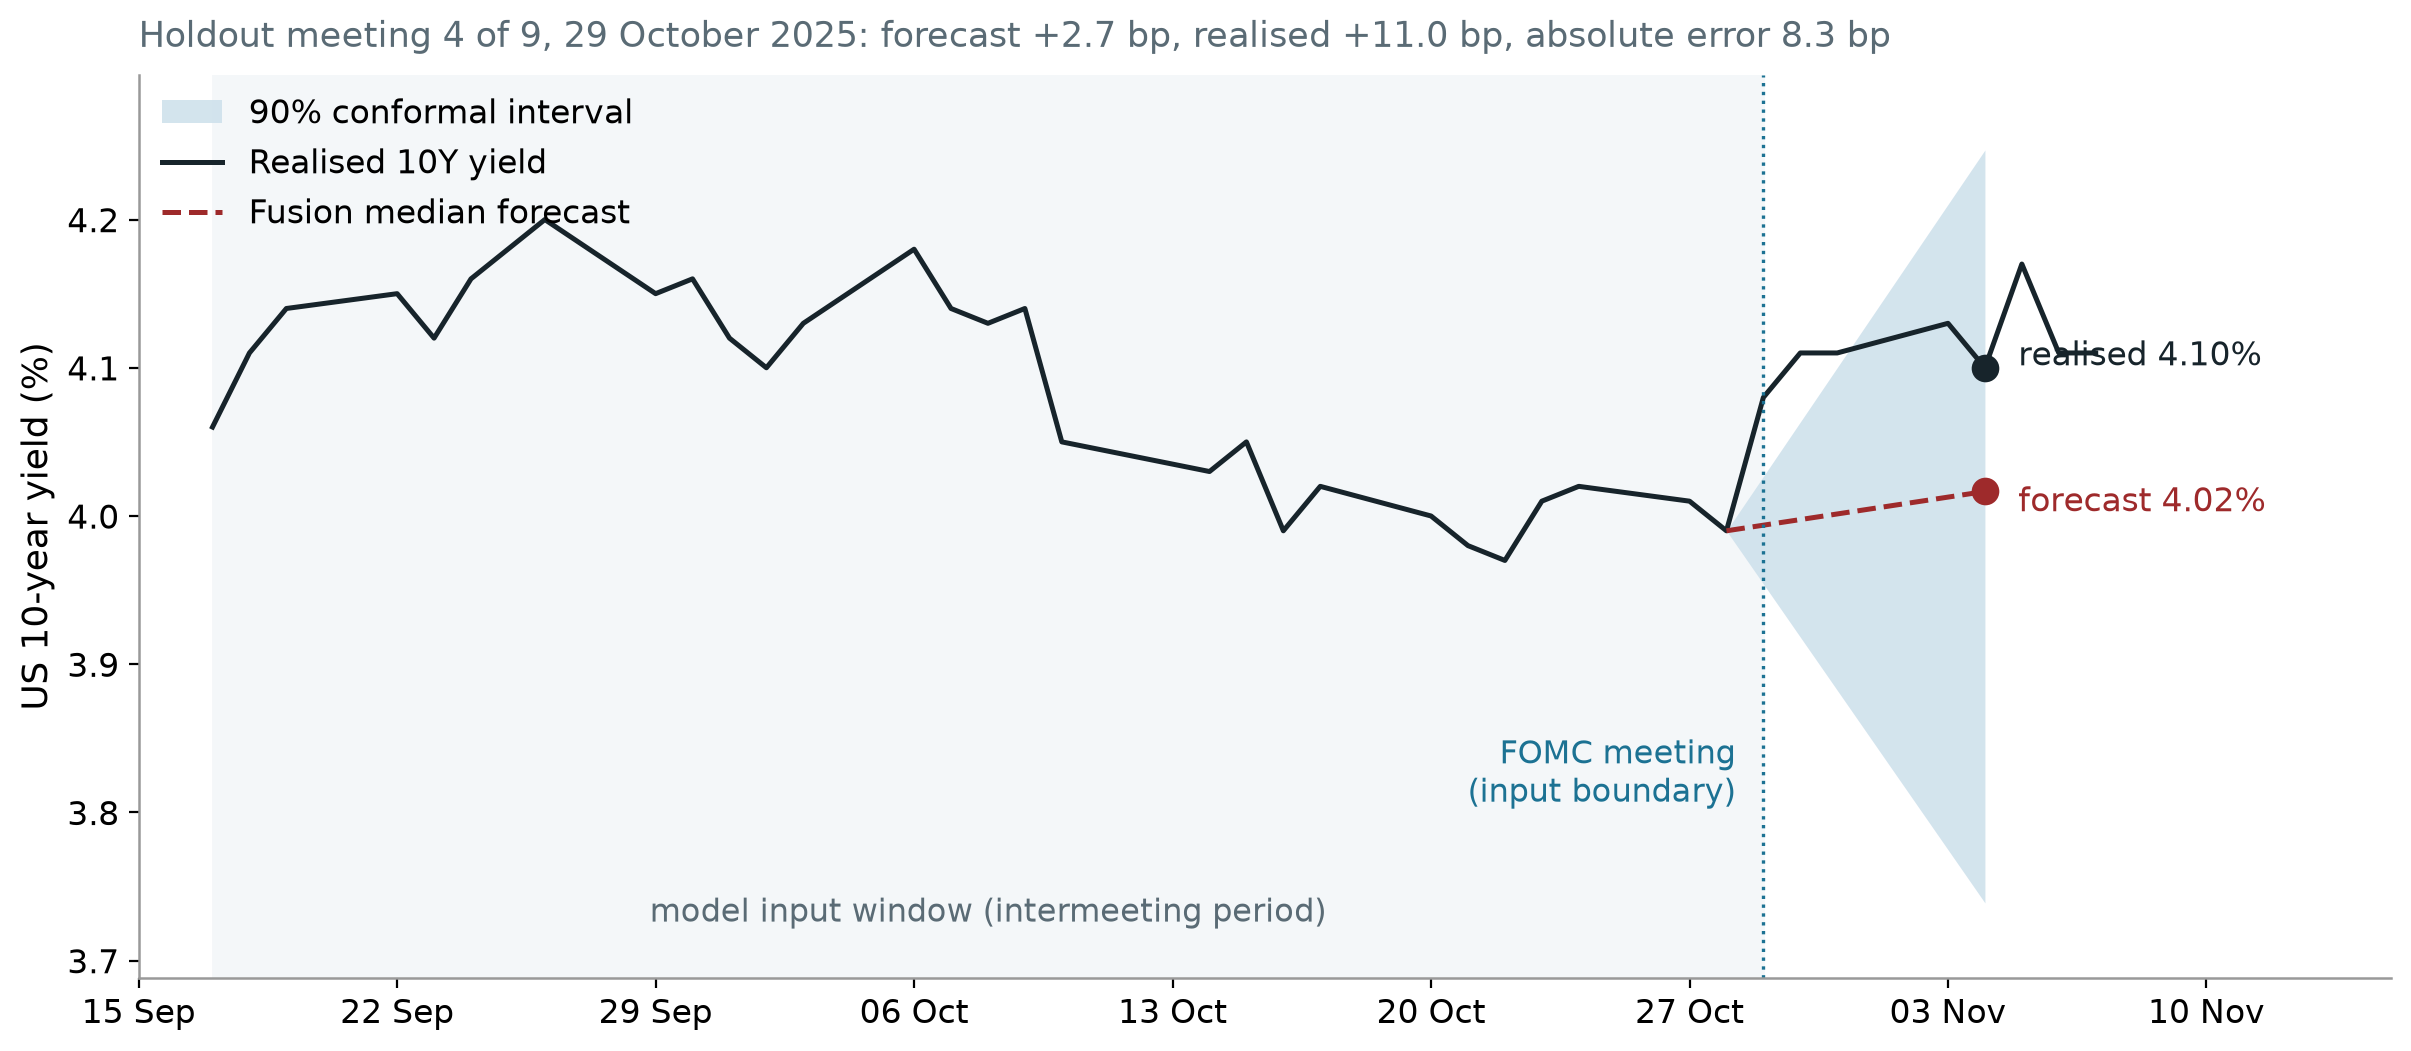

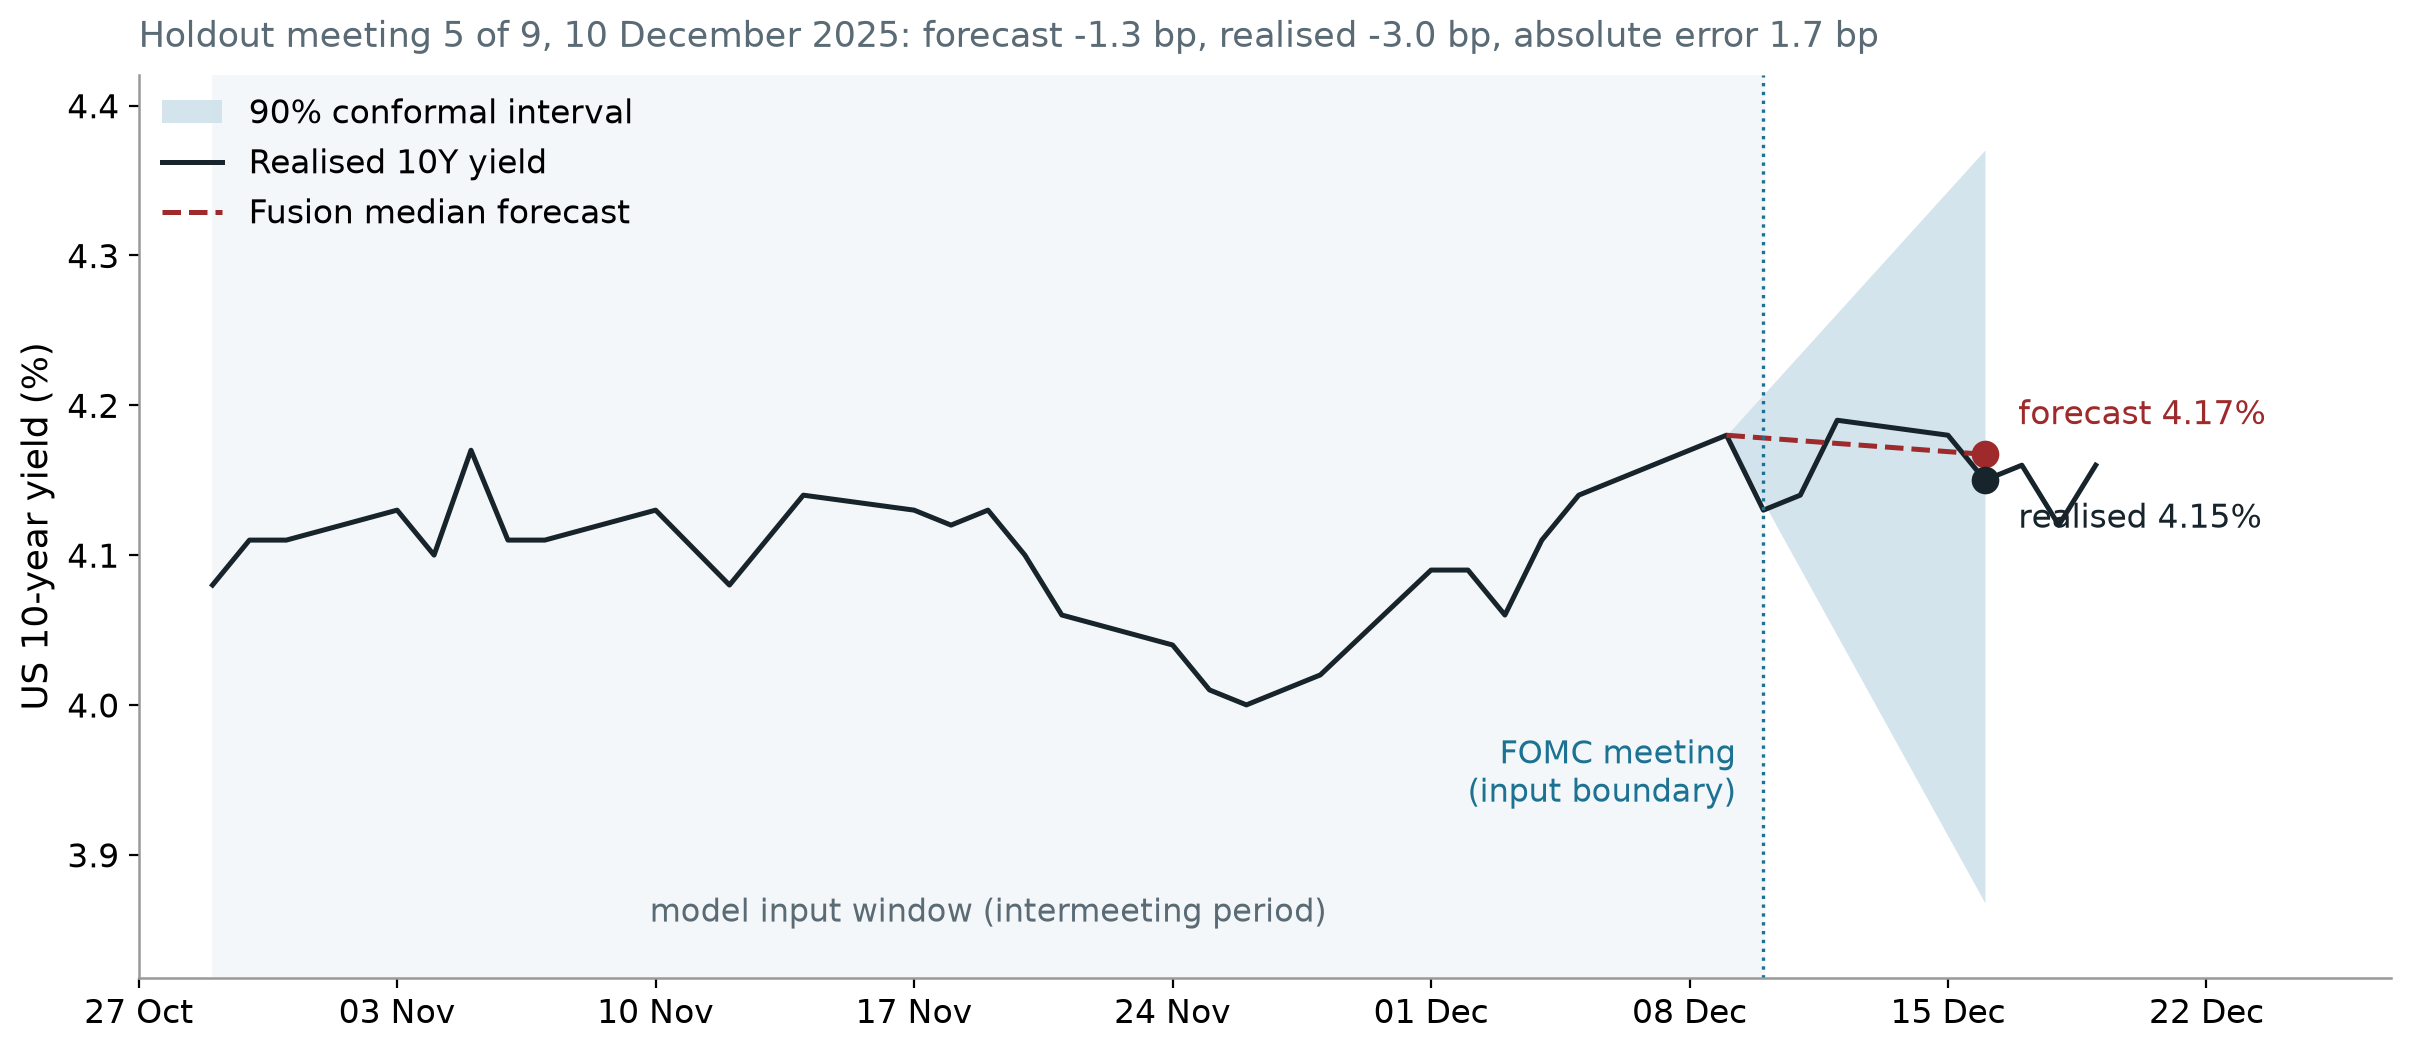

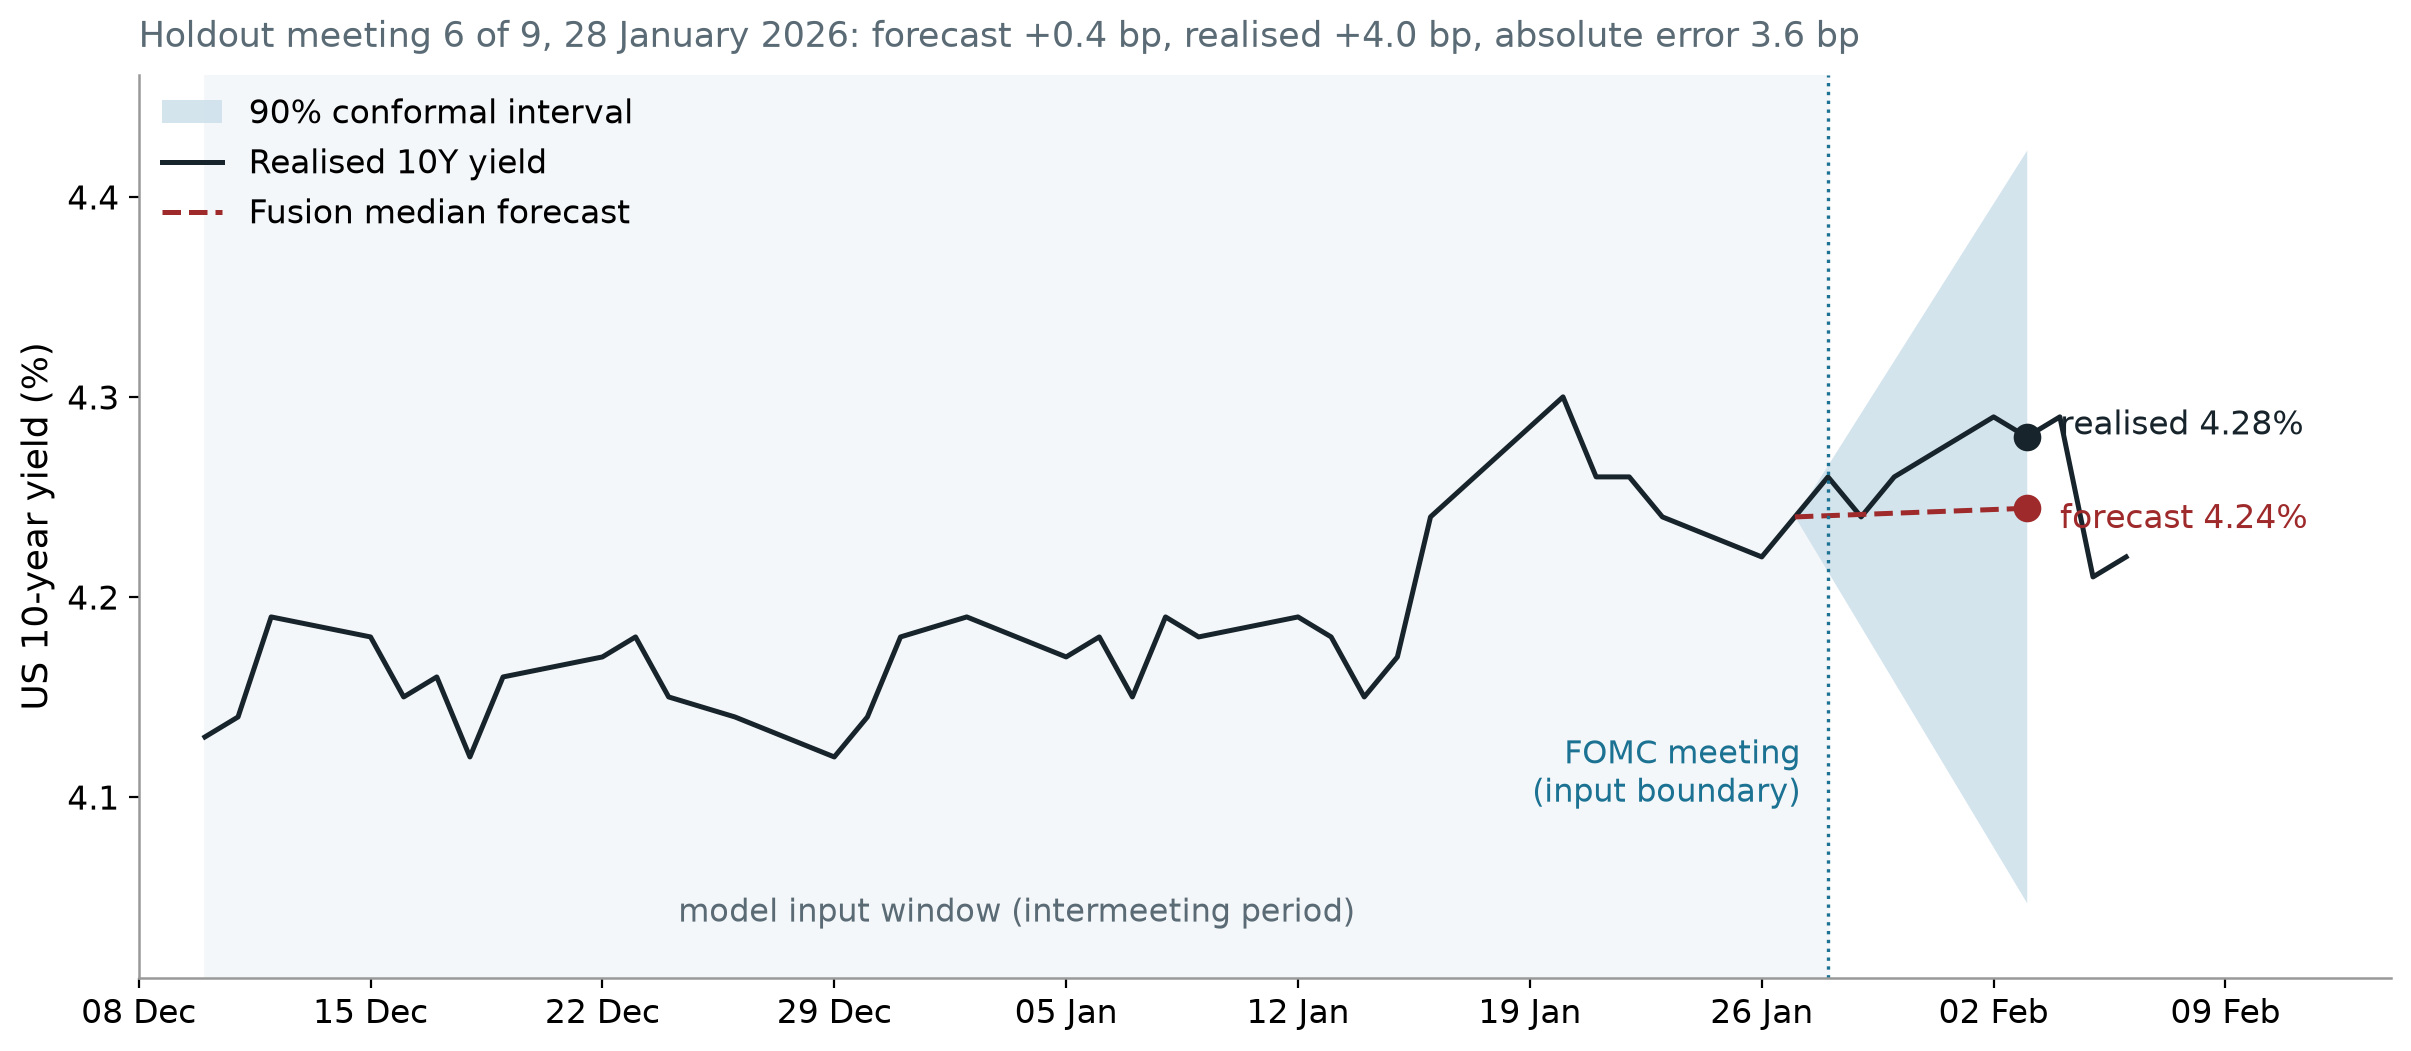

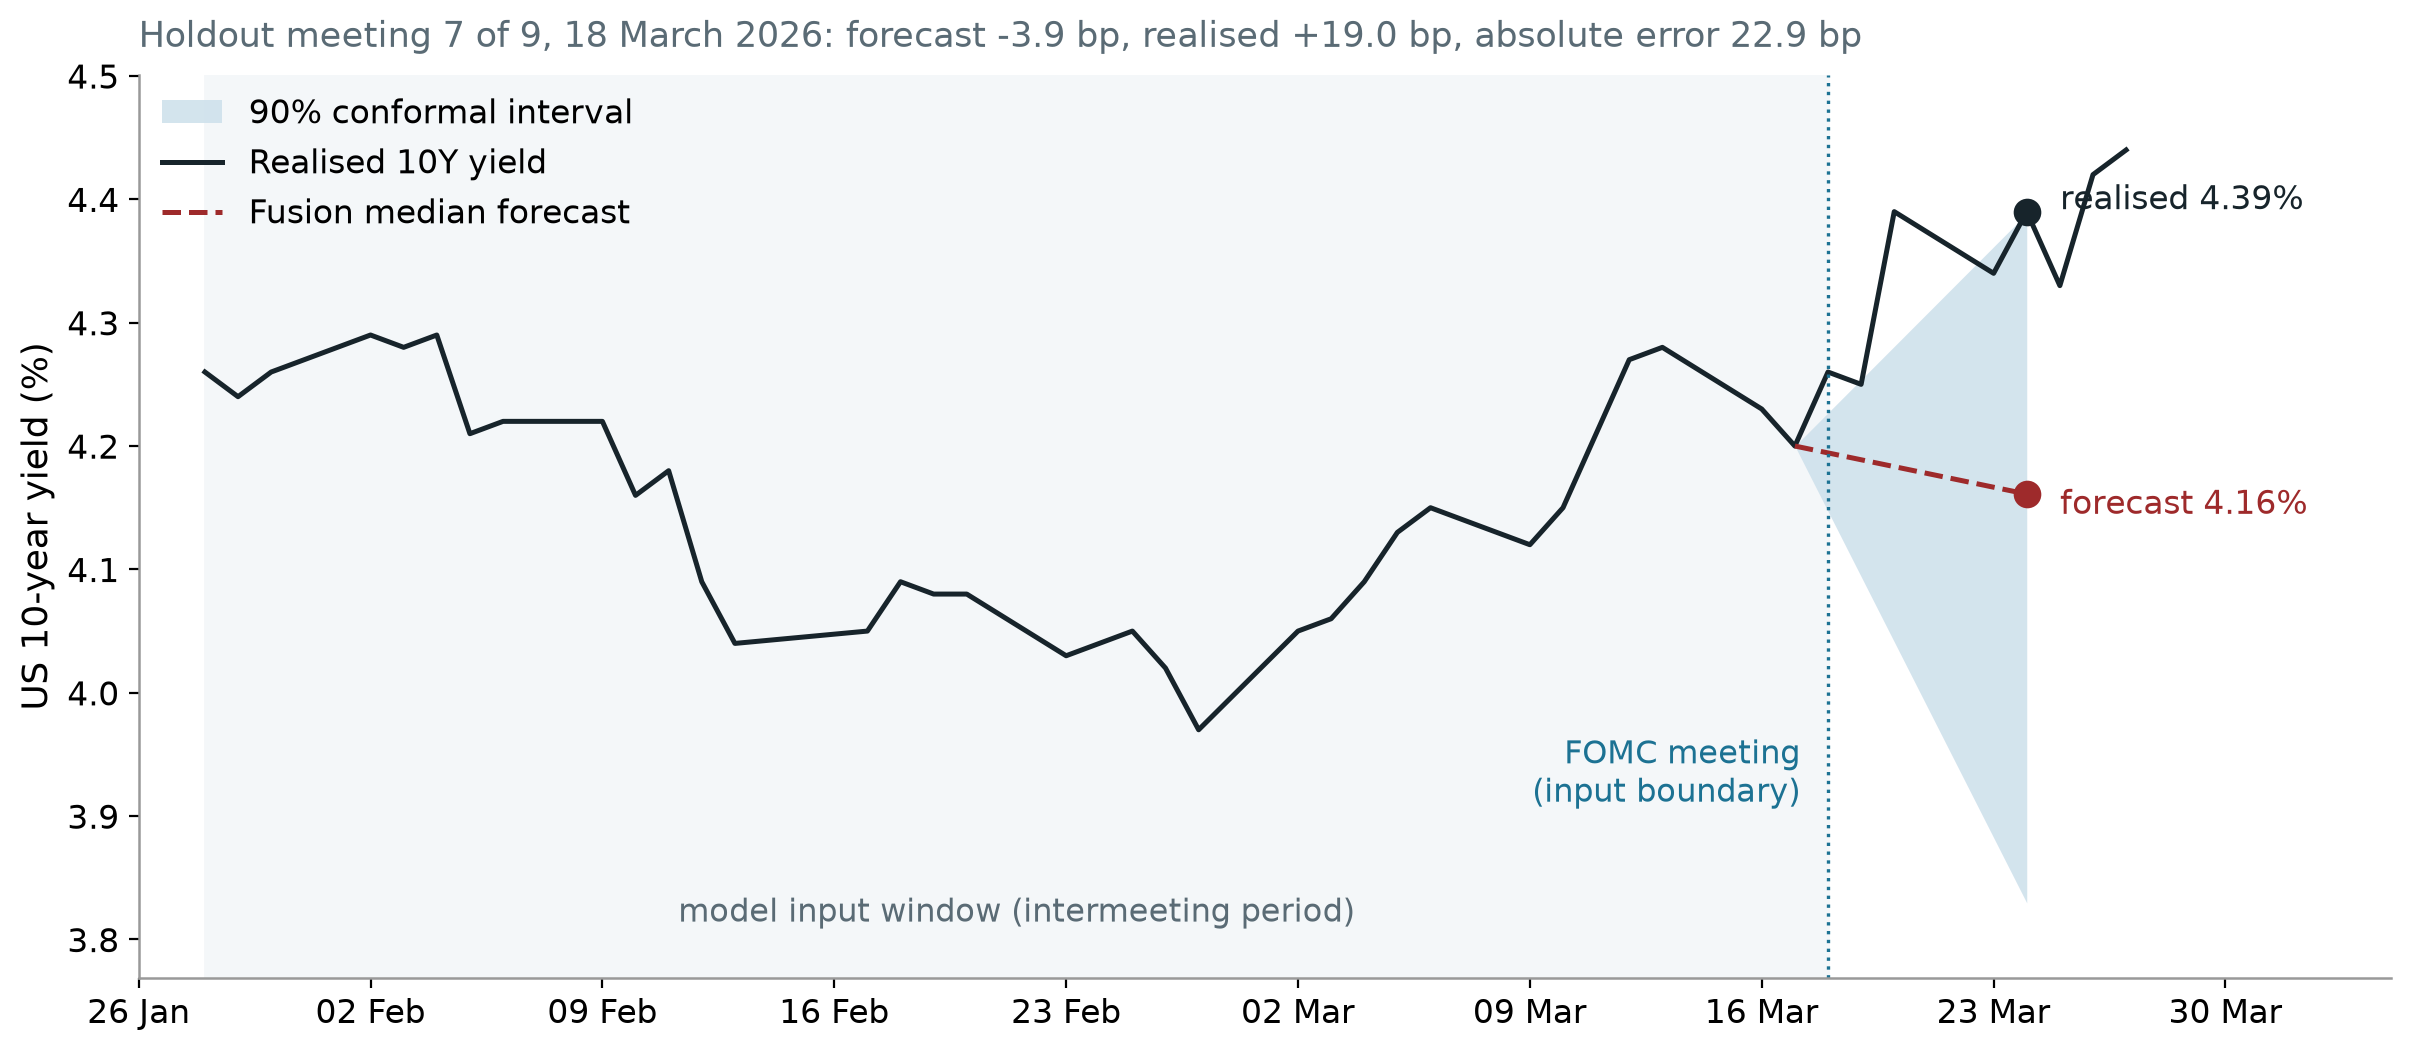

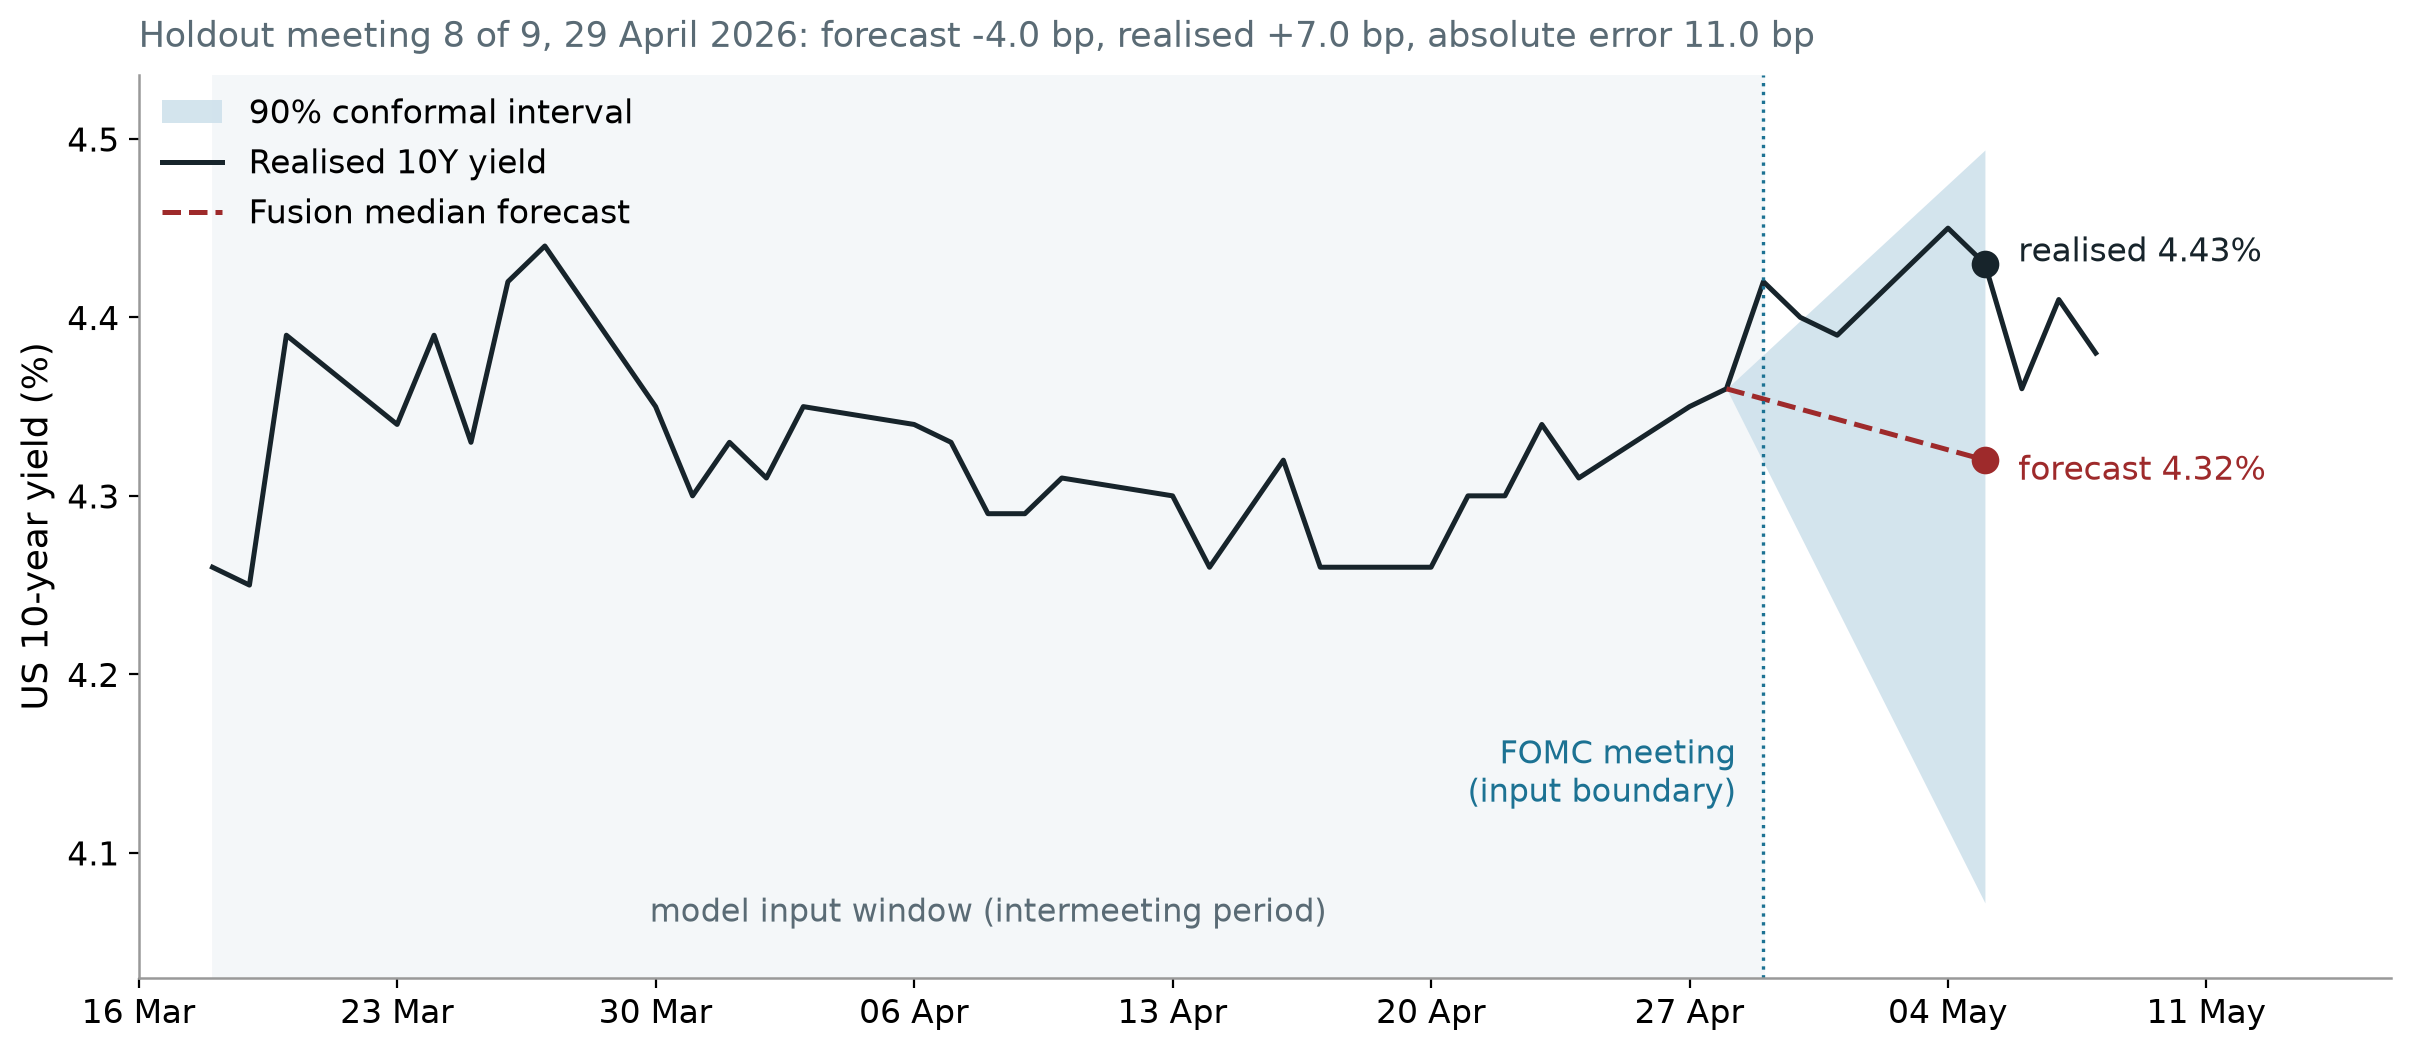

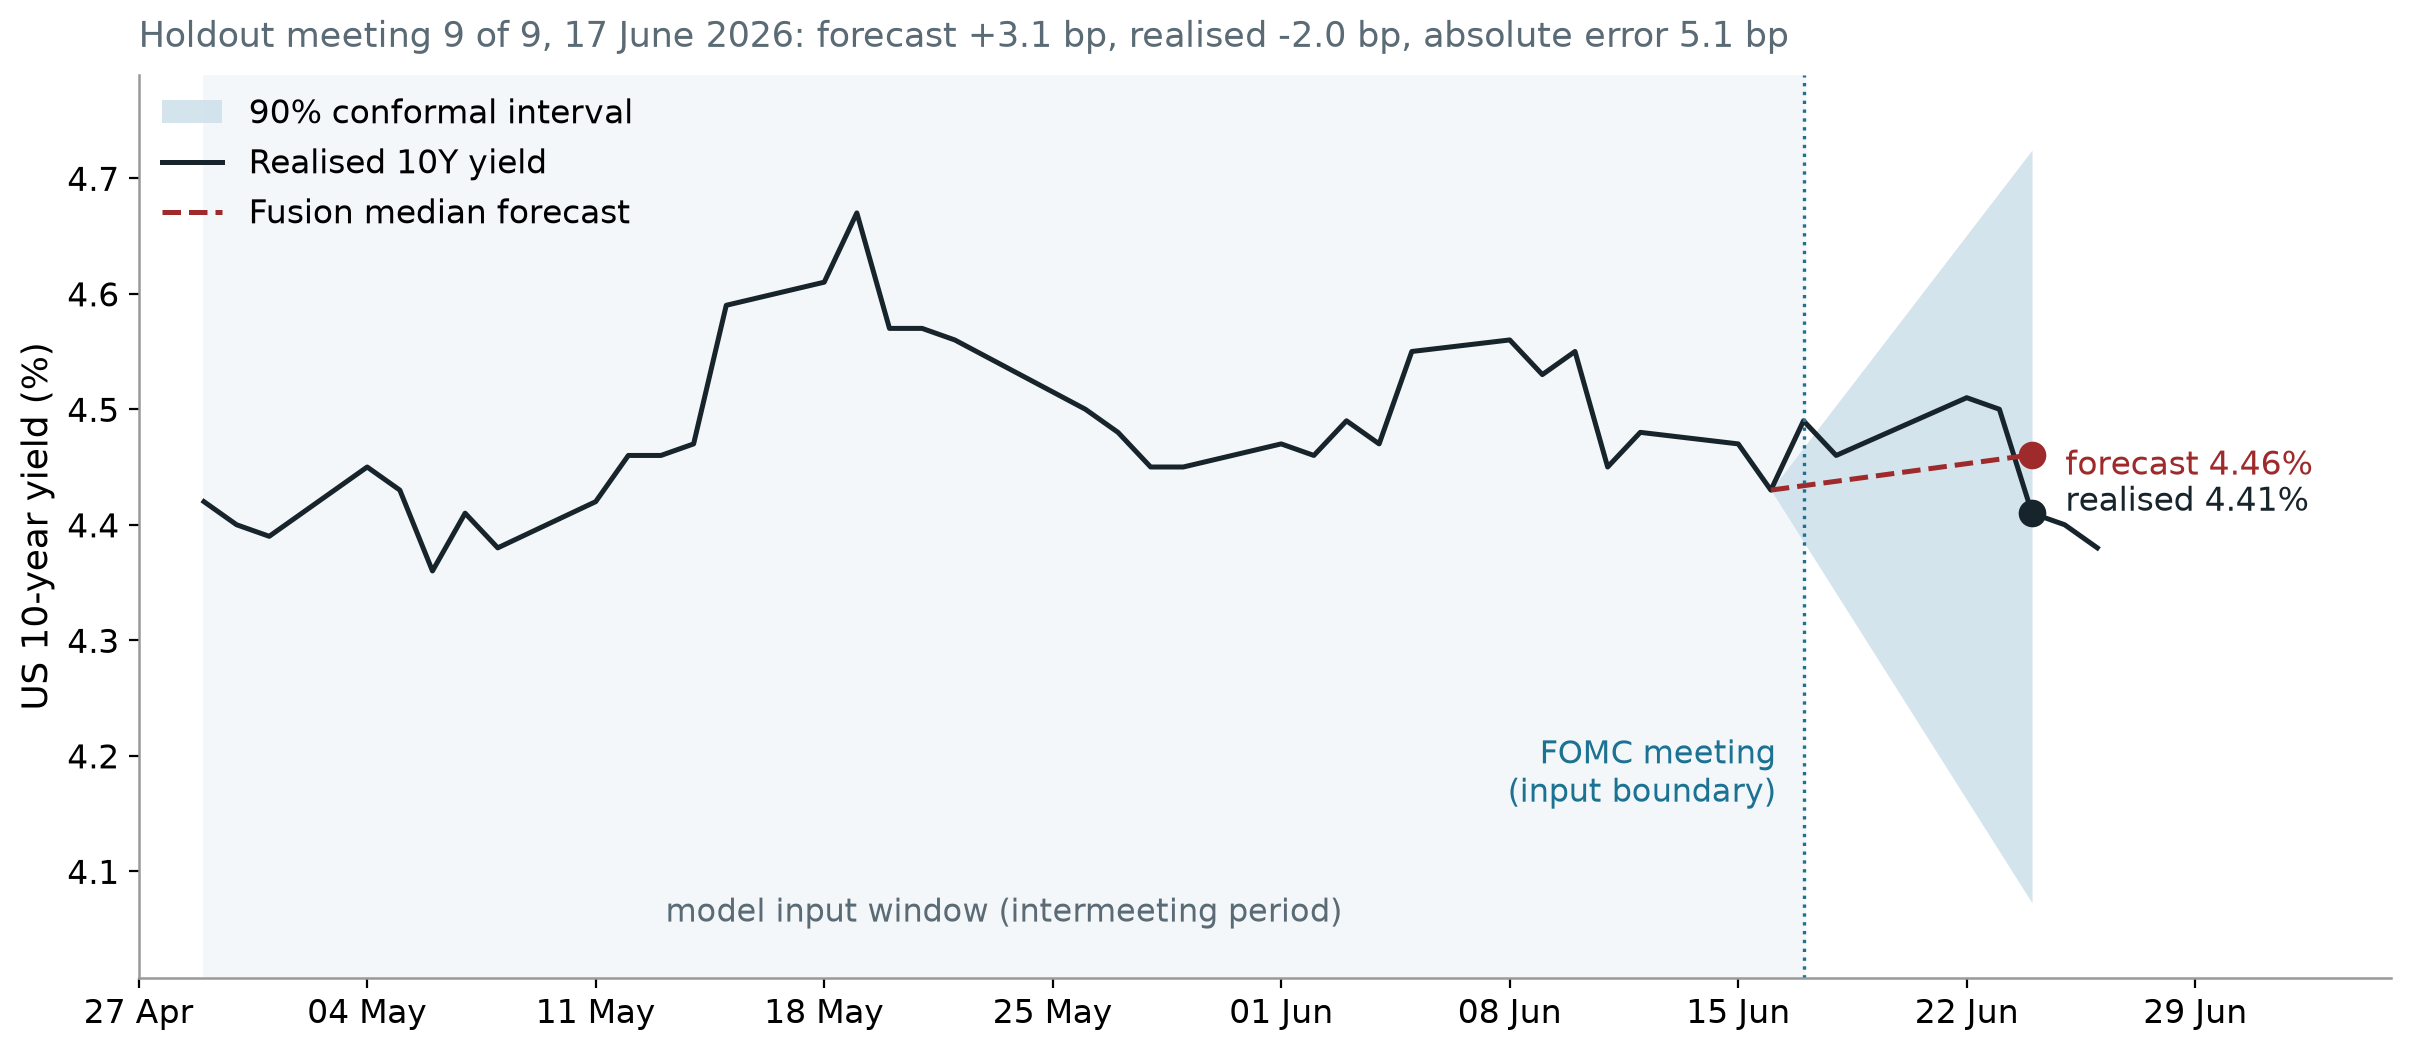

In [18]:
# Nine holdout meetings, one figure each
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TEAL, RED, GREY, LIGHT, INK = "#1C7293", "#9E2A2B", "#5A6B75", "#CFE1EC", "#17242B"

reported = pd.read_csv(
    paths.outputs / "predictions" / "walk_forward_predictions.csv",
    parse_dates=["meeting_date"],
)
all_meetings = (pd.concat([reported.meeting_date, holdout.meeting_date])
                  .sort_values().reset_index(drop=True))
y = (pd.read_csv(paths.data / "raw" / "treasury_yields.csv", parse_dates=["date"])
       .set_index("date").DGS10.dropna())

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 13, "axes.labelsize": 13, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": 0.9, "figure.dpi": 200,
})

for position, row in holdout.iterrows():
    prev = all_meetings[all_meetings < row.meeting_date].iloc[-1]
    anchor_date = y.index[y.index < row.meeting_date][-1]
    anchor = y.loc[anchor_date]
    window = y.loc[prev : row.target_date + pd.Timedelta(days=3)]

    fc   = anchor + row.fusion_bp / 100
    lo   = anchor + row.fusion_lower_bp / 100
    hi   = anchor + row.fusion_upper_bp / 100
    real = anchor + row.truth_bp / 100

    fig, ax = plt.subplots(figsize=(12, 5.2))
    ax.axvspan(prev, row.meeting_date, color="#F4F7F9", zorder=0)
    ax.fill_between([anchor_date, row.target_date], [anchor, lo], [anchor, hi],
                    color=LIGHT, alpha=0.9, lw=0, label="90% conformal interval")
    ax.plot(window.index, window.values, color=INK, lw=1.8, label="Realised 10Y yield")
    ax.plot([anchor_date, row.target_date], [anchor, fc], color=RED, lw=1.8, ls="--",
            label="Fusion median forecast")
    ax.scatter([row.target_date], [fc], s=80, color=RED, zorder=4)
    ax.scatter([row.target_date], [real], s=80, color=INK, zorder=4)
    ax.axvline(row.meeting_date, color=TEAL, lw=1.2, ls=":")

    lo_y, hi_y = min(lo, window.min()), max(hi, window.max())
    pad = (hi_y - lo_y) * 0.10
    ax.set_ylim(lo_y - pad, hi_y + pad)

    # push the two end labels apart when the forecast and the realisation nearly coincide
    span = (hi_y + pad) - (lo_y - pad)
    if abs(fc - real) < 0.06 * span:
        fc_dy, real_dy = (14, -14) if fc >= real else (-14, 14)
    else:
        fc_dy, real_dy = -4, 4

    ax.annotate("FOMC meeting\n(input boundary)", xy=(row.meeting_date, lo_y + pad * 1.2),
                xytext=(-10, 0), textcoords="offset points", ha="right", va="bottom",
                fontsize=11.5, color=TEAL)
    ax.annotate(f"forecast {fc:.2f}%", xy=(row.target_date, fc), xytext=(12, fc_dy),
                textcoords="offset points", fontsize=12, color=RED, va="center")
    ax.annotate(f"realised {real:.2f}%", xy=(row.target_date, real), xytext=(12, real_dy),
                textcoords="offset points", fontsize=12, color=INK, va="center")
    ax.text(prev + (row.meeting_date - prev) / 2, lo_y - pad * 0.35,
            "model input window (intermeeting period)",
            ha="center", va="bottom", fontsize=11.5, color=GREY)

    ax.set_ylabel("US 10-year yield (%)")
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.set_xlim(prev - pd.Timedelta(days=2), row.target_date + pd.Timedelta(days=11))
    ax.legend(frameon=False, loc="upper left", ncol=1, handlelength=1.8, borderpad=0.2)

    err = abs(row.truth_bp - row.fusion_bp)
    ax.set_title(f"Holdout meeting {position + 1} of {len(holdout)}, "
                 f"{row.meeting_date:%d %B %Y}: forecast {row.fusion_bp:+.1f} bp, "
                 f"realised {row.truth_bp:+.1f} bp, absolute error {err:.1f} bp",
                 loc="left", color=GREY, fontsize=12.5, pad=10)
    fig.tight_layout(pad=0.4)
    plt.show()